## APANPS5420 HBOS/ECOD Credit Card Anomaly Detection
### Yilin Luo

### Table of Contents

1. Introduction
2. Data Preparation
    - 2.1 Load and preview raw data
    - 2.2 clean and prepare the dataset
3. Exploratory Data Analysis
    - 3.1 Top 20 Agencies by Number of Transactions
    - 3.2 Top 20 Vendors by Number of Transactions
    - 3.3 Distribution of Transaction Amounts (Log Scale)
    - 3.4 Average Transaction Amount by Day of Week
    - 3.5 Time Trends (monthly volume and amount)
    - 3.6 Merchant Category Patterns 
4. Feature Engineering
    - 4.1 Benchmark – Single Category Average Spending Ratios (Feature 1 - 6)
    - 4.2 Benchmark – Two Categories Average Spending Ratios (Feature 7 - 12)
    - 4.3 Summary of the Engineered Ratio Features
5. Histogram-based Outlier Score (HBOS)
6. Empirical Cumulative Outlier Detection (ECOD)
7. Triangulating the predictions of Two Models (HBOS and ECOD)

### 1. Introduction

This project aims to detect anomalies in government procurement card transactions by developing a structured and scalable analytical pipeline. Using a comprehensive transactional dataset that includes cardholder details, vendor information, spending amounts, merchant categories, and transaction timestamps, the goal is to identify suspicious or unusual patterns that might indicate fraud, misuse, or policy violations. The workflow begins with thorough data preparation to clean and organize the raw data, followed by exploratory data analysis to uncover trends across agencies, vendors, transaction amounts, and time periods. Feature engineering then creates 12 ratio-based features designed to benchmark individual transactions against typical spending behaviors, both within single categories and across pairs of categories. These features serve as inputs to two anomaly detection models: Histogram-Based Outlier Score (HBOS) and Empirical Cumulative Outlier Detection (ECOD), each offering a different statistical perspective on identifying outliers. Finally, triangulating the predictions from both models allows for cross-validation and greater confidence in detecting genuine anomalies. Overall, this project provides a data-driven framework for monitoring procurement activities and enhancing financial oversight.

### 2. Data Preparation

### 2.1 Load and preview raw data 

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset
df = pd.read_csv('purchase_credit_card.csv')

# Preview the dataset shape and first few rows
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (442458, 11)


,Year-Month,Agency Number,Agency Name,Cardholder Last Name,Cardholder First Initial,Description,Amount,Vendor,Transaction Date,Posted Date,Merchant Category Code (MCC)
0,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,GENERAL PURCHASE,890.00,NACAS,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS
1,201307,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,ROOM CHARGES,368.96,SHERATON HOTEL,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,SHERATON
2,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,GENERAL PURCHASE,165.82,SEARS.COM 9300,07/29/2013 12:00:00 AM,07/31/2013 12:00:00 AM,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...
3,201307,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,GENERAL PURCHASE,96.39,WAL-MART #0137,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,"GROCERY STORES,AND SUPERMARKETS"
4,201307,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,HAMMERMILL COPY PLUS COPY EA,125.96,STAPLES DIRECT,07/30/2013 12:00:00 AM,07/31/2013 12:00:00 AM,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT..."


In [3]:
# Check current column names and get a statistical summary of numerical features
print(df.columns)     
df.describe() 

Index(['Year-Month', 'Agency Number', 'Agency Name', 'Cardholder Last Name',
       'Cardholder First Initial', 'Description', 'Amount', 'Vendor',
       'Transaction Date', 'Posted Date', 'Merchant Category Code (MCC)'],
      dtype='object')


,Year-Month,Agency Number,Amount
count,442458.000000,442458.000000,4.424580e+05
mean,201357.284375,42785.860353,4.249912e+02
std,47.107417,33378.461293,5.266509e+03
min,201307.000000,1000.000000,-4.286304e+04
25%,201309.000000,1000.000000,3.091000e+01
50%,201401.000000,47700.000000,1.048900e+02
75%,201404.000000,76000.000000,3.450000e+02
max,201406.000000,98000.000000,1.903858e+06


### 2.2 Clean and prepare the dataset

In [4]:
# Step 1: change column names 
df.columns = ['Year_Month', 'Agency_Number', 'Agency_Name', 'Cardholder_Last_Name',
      'Cardholder_First_Initial', 'Description', 'Amount', 'Vendor', 'Transaction_Date',
      'Posted_Date', 'Merchant_Category']

In [5]:
# Step 2: Convert date columns to datetime format using specified pattern
date_format = '%m/%d/%Y %I:%M:%S %p'  # Matches "07/30/2013 12:00:00 AM"
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'], format=date_format, errors='coerce')
df['Posted_Date'] = pd.to_datetime(df['Posted_Date'], format=date_format, errors='coerce')

# Step 3: Convert 'Year_Month' to proper datetime format
df['Year_Month'] = pd.to_datetime(df['Year_Month'], format='%Y%m')

# Step 4: Create time-based features
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month
df['Week_Number'] = df['Transaction_Date'].dt.isocalendar().week

# Step 5: Map numeric weekday to string name
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['Day_of_Week'] = df['Transaction_Date'].dt.dayofweek.map(day_map)

# Step 6: Combine cardholder initials and last name into a single field
df['Cardholder_Name'] = (
    df['Cardholder_First_Initial'].astype(str).str.strip() + " " +
    df['Cardholder_Last_Name'].astype(str).str.strip()
)

# Ensure the combined name is stored as a string
df['Cardholder_Name'] = df['Cardholder_Name'].astype(str)

# Final check
df.head()

,Year_Month,Agency_Number,Agency_Name,Cardholder_Last_Name,Cardholder_First_Initial,Description,Amount,Vendor,Transaction_Date,Posted_Date,Merchant_Category,Year,Month,Week_Number,Day_of_Week,Cardholder_Name
0,2013-07-01,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,GENERAL PURCHASE,890.00,NACAS,2013-07-30,2013-07-31,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,2013,7,31,Tuesday,C Mason
1,2013-07-01,1000,OKLAHOMA STATE UNIVERSITY,Mason,C,ROOM CHARGES,368.96,SHERATON HOTEL,2013-07-30,2013-07-31,SHERATON,2013,7,31,Tuesday,C Mason
2,2013-07-01,1000,OKLAHOMA STATE UNIVERSITY,Massey,J,GENERAL PURCHASE,165.82,SEARS.COM 9300,2013-07-29,2013-07-31,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,2013,7,31,Monday,J Massey
3,2013-07-01,1000,OKLAHOMA STATE UNIVERSITY,Massey,T,GENERAL PURCHASE,96.39,WAL-MART #0137,2013-07-30,2013-07-31,"GROCERY STORES,AND SUPERMARKETS",2013,7,31,Tuesday,T Massey
4,2013-07-01,1000,OKLAHOMA STATE UNIVERSITY,Mauro-Herrera,M,HAMMERMILL COPY PLUS COPY EA,125.96,STAPLES DIRECT,2013-07-30,2013-07-31,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",2013,7,31,Tuesday,M Mauro-Herrera


### 3. Exploratory Data Analysis (EDA)

The Exploratory Data Analysis (EDA) phase provides a comprehensive overview of the procurement transaction dataset, helping us understand key patterns, trends, and potential anomalies before feature engineering. We begin by identifying the top 20 agencies and vendors by transaction volume to highlight major participants. Then, we examine the distribution of transaction amounts—using a log scale to reveal outliers—and explore how average spending varies across days of the week. Monthly trends in both transaction volume and total spending are visualized to detect seasonality or structural shifts. Finally, we investigate merchant category patterns to understand spending behavior across different goods and services. These insights lay the groundwork for building targeted anomaly detection features.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme for better visuals
sns.set(style="whitegrid")

### 3.1 Top 20 Agencies by Number of Transactions

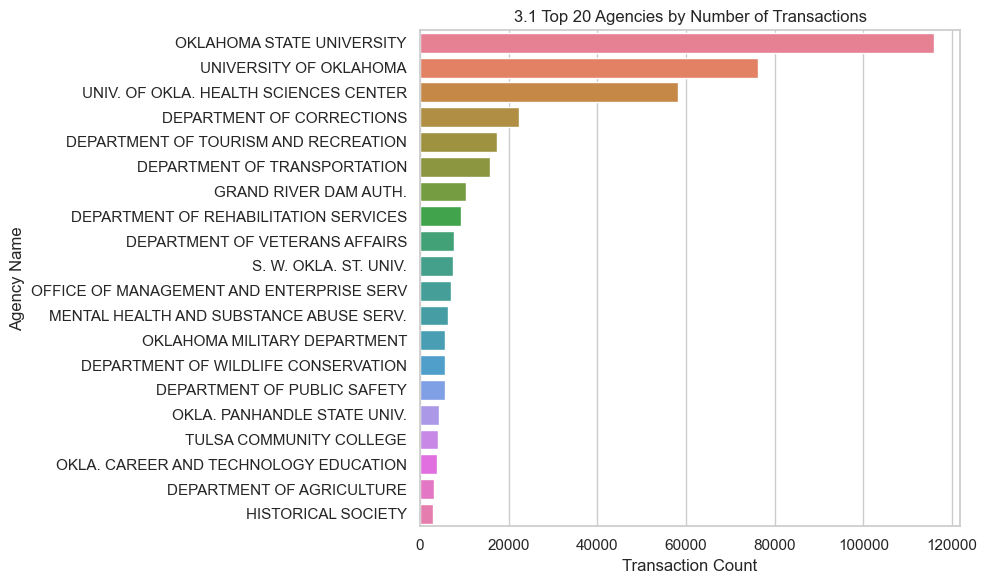

In [7]:
# Plot top 20 agencies by number of transactions
agency_counts = df['Agency_Name'].value_counts().head(20)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=agency_counts.values,
    y=agency_counts.index,
    hue=agency_counts.index,     # Set hue explicitly
    dodge=False,
    legend=False                 # Disable redundant legend
)
plt.title("3.1 Top 20 Agencies by Number of Transactions")
plt.xlabel("Transaction Count")
plt.ylabel("Agency Name")
plt.tight_layout()
plt.show()

Finding:

Oklahoma State University has the highest number of purchase card transactions,leads with over 115,000 transactions, followed by University of Oklahoma and Univ. of Okla. Health Sciences Center. The top three agencies alone contribute a significantly higher volume of transactions compared to others. This suggests that higher education institutions dominate purchase card activity, likely due to decentralized operations and departmental spending.

### 3.2 Top 20 Vendors by Number of Transactions

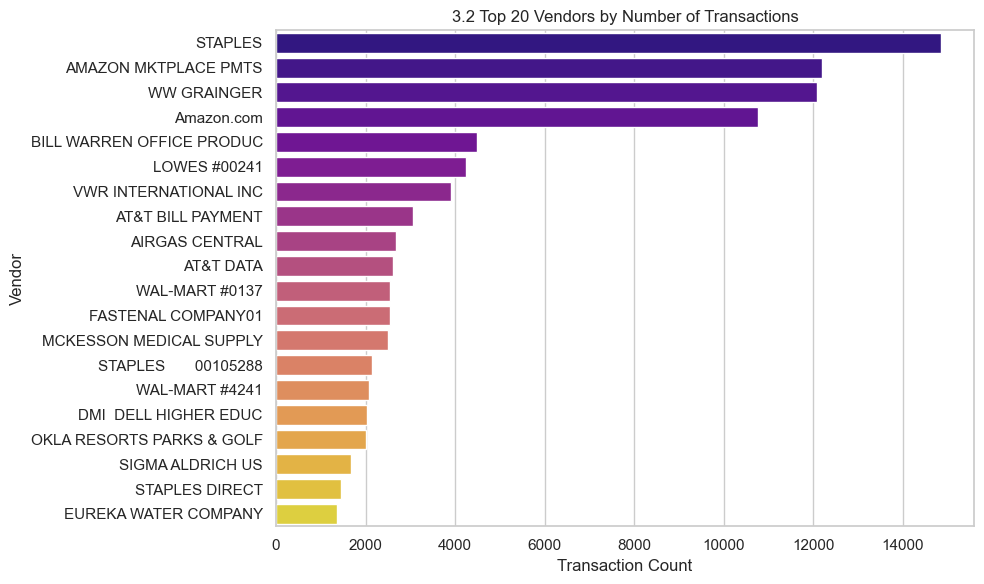

In [8]:
# Plot top 20 vendors by number of transactions
vendor_counts = df['Vendor'].value_counts().head(20)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=vendor_counts.values,
    y=vendor_counts.index,
    hue=vendor_counts.index,     # Explicitly assign hue
    dodge=False,
    legend=False,                # Hide redundant legend
    palette="plasma"
)
plt.title("3.2 Top 20 Vendors by Number of Transactions")
plt.xlabel("Transaction Count")
plt.ylabel("Vendor")
plt.tight_layout()
plt.show()

Finding:

STAPLES is the leading vendor with over 14,000 transactions, followed closely by Amazon Marketplace Payments and WW Grainger. The top vendors include major suppliers of office products, hardware, utilities, and technology services, indicating that a large portion of government purchasing is concentrated in operational and infrastructure-related categories.

### 3.3 Distribution of Transaction Amounts (Log Scale)

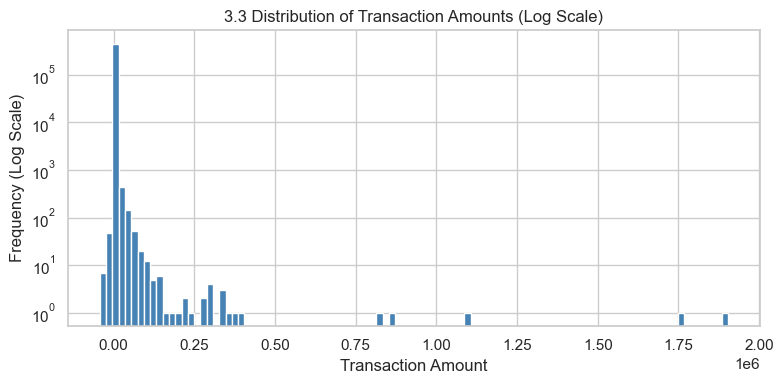

In [9]:
# Plot the distribution of transaction amounts (Log Scale)
plt.figure(figsize=(8, 4))
plt.hist(df['Amount'], bins=100, color='steelblue', log=True)
plt.title("3.3 Distribution of Transaction Amounts (Log Scale)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency (Log Scale)")
plt.tight_layout()
plt.show()

Finding:

The distribution of transaction amounts is highly right-skewed, with the vast majority of purchases concentrated below $1,000. A small number of transactions extend into the tens of thousands or even millions, indicating the presence of extreme outliers or high-value purchases. The log scale on the y-axis further highlights how rare these large transactions are, suggesting they warrant closer attention in anomaly detection or auditing.

### 3.4 Average Transaction Amount by Day of Week 

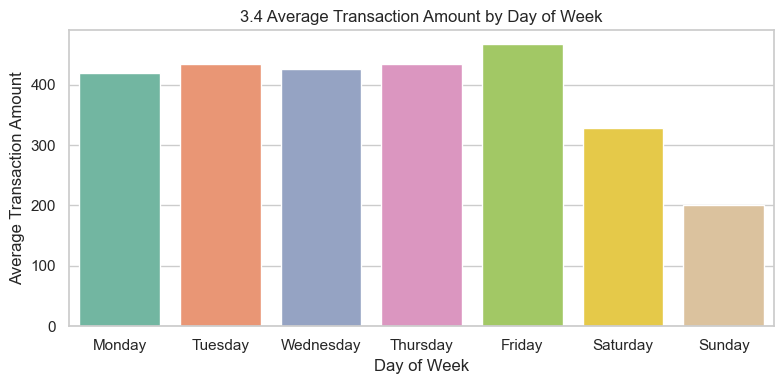

In [10]:
# Plot the average transaction amount by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_avg = df.groupby('Day_of_Week')['Amount'].mean().reindex(day_order).reset_index()

plt.figure(figsize=(8, 4))
sns.barplot(
    data=day_avg,
    x='Day_of_Week',
    y='Amount',
    hue='Day_of_Week',      # Explicitly set hue
    palette='Set2',
    dodge=False,
    legend=False            # No need to show redundant legend
)
plt.title("3.4 Average Transaction Amount by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Transaction Amount")
plt.tight_layout()
plt.show()

Finding:

The average transaction amounts are highest on Fridays, followed closely by Tuesday through Thursday, suggesting that most high-value purchasing activity occurs during the standard workweek. In contrast, Saturdays and Sundays show noticeably lower averages, with Sunday having the lowest, indicating minimal procurement activity on weekends. This pattern aligns with expected government work schedules and may help in identifying out-of-pattern spending on weekends.

### 3.5 Time Trends (monthly volume and amount)

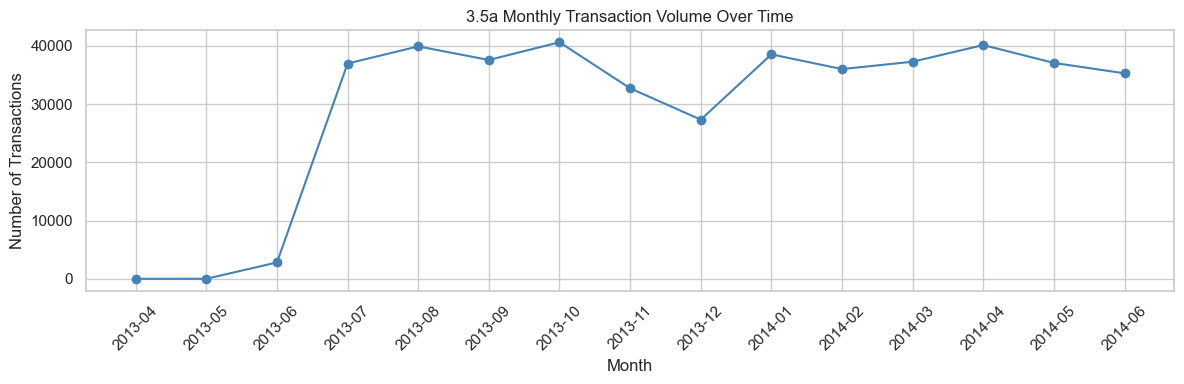

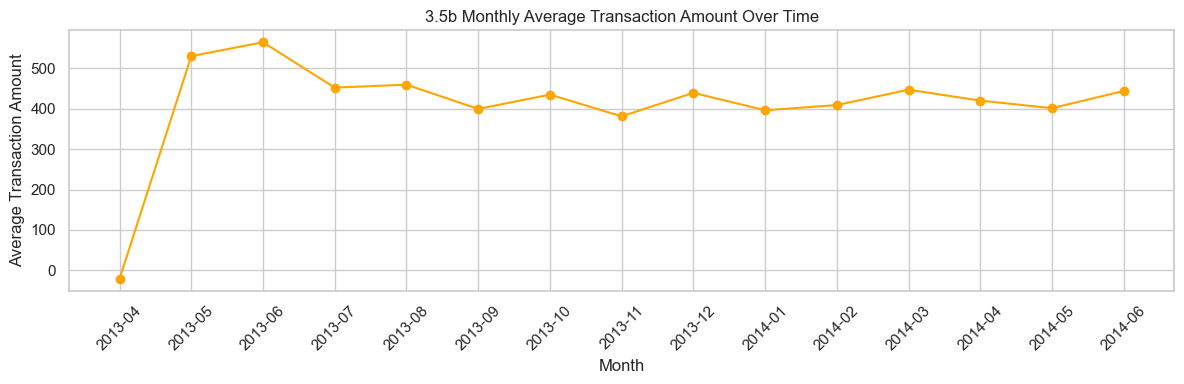

In [11]:
# Plot time trends: monthly volume and average transaction amount

# Create a 'YearMonth' field for grouping
df['YearMonth'] = df['Transaction_Date'].dt.to_period('M').astype(str)

# Aggregate monthly stats
monthly_stats = df.groupby('YearMonth').agg(
    Transaction_Count=('Amount', 'count'),
    Average_Amount=('Amount', 'mean')
).reset_index()

# Plot 3.5a: Monthly Transaction Volume
plt.figure(figsize=(12, 4))
plt.plot(monthly_stats['YearMonth'], monthly_stats['Transaction_Count'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title("3.5a Monthly Transaction Volume Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3.5b: Monthly Average Transaction Amount
plt.figure(figsize=(12, 4))
plt.plot(monthly_stats['YearMonth'], monthly_stats['Average_Amount'], marker='o', color='orange')
plt.xticks(rotation=45)
plt.title("3.5b Monthly Average Transaction Amount Over Time")
plt.xlabel("Month")
plt.ylabel("Average Transaction Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

Finding:

From July 2013 onward, transaction volume stabilized at a high level (30,000–40,000 transactions per month), indicating consistent procurement activity across the fiscal year. Notably, there was a sharp increase between June and July, possibly due to fiscal year budgeting cycles. The average transaction amount fluctuated between 400 dolllars and 500 dollars per month, with occasional peaks, such as in August 2013. These stable yet slightly varying trends may help in detecting temporal anomalies if any month significantly deviates from this pattern.

### 3.6 Merchant Category Patterns

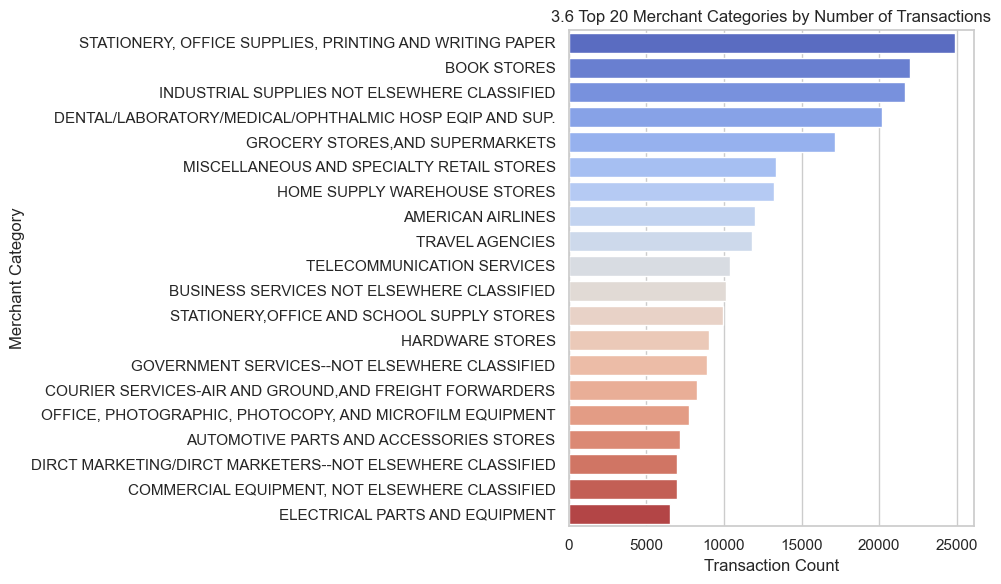

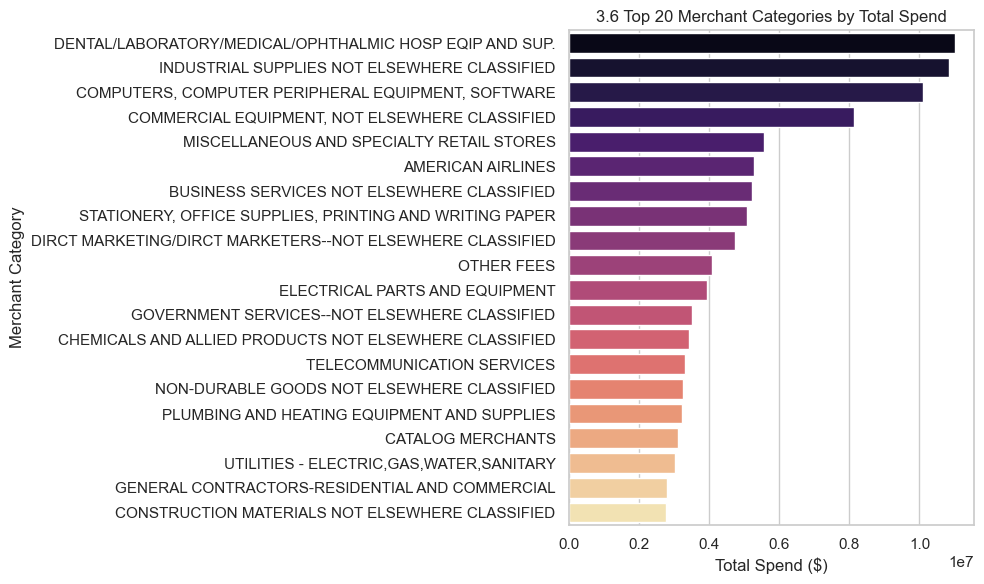

In [12]:
# Plot merchant category patterns: top 20 categories by transaction count
merchant_counts = df['Merchant_Category'].value_counts().head(20)

# Plot the top 20 merchant categories
plt.figure(figsize=(10, 6))
sns.barplot(x=merchant_counts.values, y=merchant_counts.index, palette="coolwarm", hue=merchant_counts.index, legend=False)
plt.title("3.6 Top 20 Merchant Categories by Number of Transactions")
plt.xlabel("Transaction Count")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

# (continued): Top 20 merchant categories by total spend
merchant_total_spend = df.groupby('Merchant_Category')['Amount'].sum().sort_values(ascending=False).head(20)

# Plot top 20 merchant categories by total spend
plt.figure(figsize=(10, 6))
sns.barplot(x=merchant_total_spend.values, y=merchant_total_spend.index, palette="magma", hue=merchant_total_spend.index, legend=False)
plt.title("3.6 Top 20 Merchant Categories by Total Spend")
plt.xlabel("Total Spend ($)")
plt.ylabel("Merchant Category")
plt.tight_layout()
plt.show()

Finding:

The most frequently used merchant categories are office-related and operational, with “STATIONERY, OFFICE SUPPLIES, PRINTING AND WRITING PAPER” leading in transaction count, followed by “BOOK STORES” and “INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED”. These high-frequency categories suggest regular small-scale purchases necessary for day-to-day government functions.

In contrast, the top merchant categories by total spending highlight areas of high-cost procurement. “DENTAL/LABORATORY/MEDICAL/OPHTHALMIC HOSP EQIP AND SUP.” and “INDUSTRIAL SUPPLIES” top the list, with spending reaching nearly $10 million. Categories like “COMPUTERS” and “COMMERCIAL EQUIPMENT” also appear, suggesting that while some purchases are infrequent, their financial impact is significant. This contrast between frequency and spend highlights the need for anomaly detection not only in frequent purchases but also in rare, high-value transactions.

### 4. Feature Engineering

In this section, we develop 14 targeted features designed to detect anomalies by comparing each transaction’s spending amount against relevant benchmarks. The first seven features calculate the ratio of the transaction amount to the average spending benchmarked by single categorical dimensions such as vendor, month, description, or agency. The following seven features extend this idea by computing ratios relative to benchmarks defined by pairs of categories—for example, average spending by agency and vendor, or by merchant category and weekday. These ratio-based features transform raw dollar amounts into interpretable signals of deviation, helping to highlight transactions that are significantly higher or lower than typical patterns in their respective contexts. Together, they provide a robust framework for identifying outliers and potential anomalies across diverse facets of the procurement data.

### 4.1 Benchmark – Single Category Average Spending Ratios

### Feature 1: Ratio to Average Spending by Vendor (ratio_vendor_avg_amount)

Definition: 

This feature divides the transaction amount by the historical average amount spent at the same vendor across the entire dataset.

In [13]:
# Feature Creation 

# Calculate average spending per Vendor
vendor_avg = (
    df.groupby('Vendor')['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_vendor_amount'})
)

# Merge average vendor spending back into original data
feature_df_1 = df.merge(
    vendor_avg,
    on='Vendor',
    how='left'
)

# Calculate the ratio
feature_df_1['ratio_vendor_avg_amount'] = np.where(
    feature_df_1['avg_vendor_amount'] == 0,
    0,
    feature_df_1['Amount'] / feature_df_1['avg_vendor_amount']
)

# Preview the new feature
feature_df_1[['Vendor', 'Amount', 'avg_vendor_amount', 'ratio_vendor_avg_amount']].head()

,Vendor,Amount,avg_vendor_amount,ratio_vendor_avg_amount
0,NACAS,890.00,715.555556,1.243789
1,SHERATON HOTEL,368.96,214.383270,1.721030
2,SEARS.COM 9300,165.82,163.750339,1.012639
3,WAL-MART #0137,96.39,62.405600,1.544573
4,STAPLES DIRECT,125.96,144.875697,0.869435


In [14]:
# Summarize the ratio feature
feature_df_1['ratio_vendor_avg_amount'].describe()

count    4.424580e+05
mean     9.940932e-01
std      9.397680e+13
min     -1.804536e+16
25%      2.755939e-01
50%      7.897228e-01
75%      1.026768e+00
max      5.413608e+16
Name: ratio_vendor_avg_amount, dtype: float64

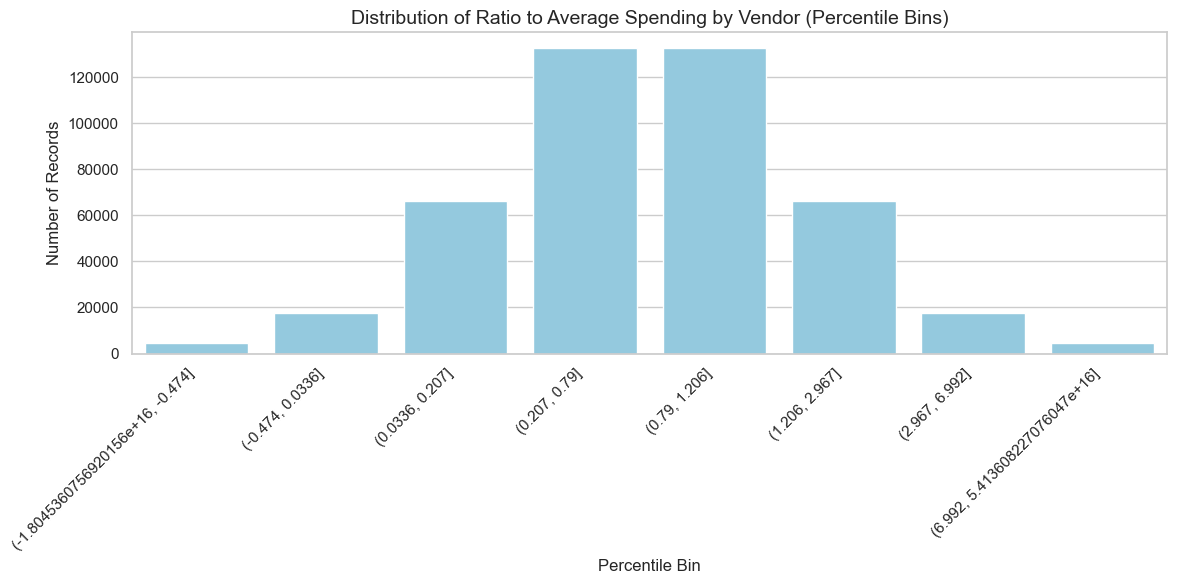

In [15]:
# Binning for distribution plotting

# Define variable and percentiles
var = 'ratio_vendor_avg_amount'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_1[binned_var] = pd.qcut(
    feature_df_1[var],
    q=percentiles,
    duplicates='drop'
)

# Get bin interval labels as strings
xticklabels = feature_df_1[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_1, color='skyblue')

# Set ticks and labels explicitly
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')

plt.title('Distribution of Ratio to Average Spending by Vendor (Percentile Bins)', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [16]:
# Define high anomaly threshold
threshold = 6.992

# Flag anomalies where the ratio exceeds the threshold
feature_df_1['Anomaly_ratio_vendor_avg_amount'] = (
    feature_df_1['ratio_vendor_avg_amount'] > threshold
).astype(int)

# Count number of anomalies
num_anomalies = feature_df_1['Anomaly_ratio_vendor_avg_amount'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4426


In [17]:
# Preview top anomalies
anomalies_f1 = feature_df_1[
    feature_df_1['Anomaly_ratio_vendor_avg_amount'] == 1
][
    ['Vendor', 'Amount', 'avg_vendor_amount', 'ratio_vendor_avg_amount']
].sort_values('ratio_vendor_avg_amount', ascending=False)

anomalies_f1.head()

,Vendor,Amount,avg_vendor_amount,ratio_vendor_avg_amount
311657,TRAVRES HotelPlanner,769.32,1.421085e-14,5.413608e+16
422221,GODADDY.COM CANADA,6.65,1.000000e-02,6.650000e+02
384436,BLUEBYTE TRADING LLC,1882.02,2.840000e+00,6.626831e+02
3659,OFFICE DEPOT #47,-299.98,-6.877778e-01,4.361583e+02
80683,WW GRAINGER,96190.38,4.214489e+02,2.282373e+02


The feature 1, Ratio to Average Spending by Vendor,is valuable because it adjusts each transaction for the vendor’s typical spending pattern. It helps spot unusually high payments that might signal fraud, overbilling, or errors specific to that vendor. This context-aware feature makes anomaly detection more precise than using raw amounts alone.

### Feature 2: Ratio to Average Spending by Merchant Category (ratio_category_avg_amount)

Definition:

This feature divides the transaction amount by the historical average amount spent in the same merchant category across the entire dataset.

In [18]:
# Step 1: Feature Creation – time_since_last_merchant_txn

# Compute average spending per merchant category
category_avg = (
    df.groupby('Merchant_Category')['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_category_amount'})
)

# Merge the category average back into the main dataset
feature_df_2 = df.merge(
    category_avg,
    on='Merchant_Category',
    how='left'
)

# Calculate the ratio safely
feature_df_2['ratio_category_avg_amount'] = np.where(
    feature_df_2['avg_category_amount'] == 0,
    0,
    feature_df_2['Amount'] / feature_df_2['avg_category_amount']
)

# Preview the new feature
feature_df_2[['Merchant_Category', 'Amount', 'avg_category_amount', 'ratio_category_avg_amount']].head()

,Merchant_Category,Amount,avg_category_amount,ratio_category_avg_amount
0,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,890.00,480.051482,1.853968
1,SHERATON,368.96,389.172289,0.948063
2,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,165.82,676.519181,0.245108
3,"GROCERY STORES,AND SUPERMARKETS",96.39,74.121967,1.300424
4,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",125.96,204.915215,0.614693


In [19]:
# Summarize the new ratio feature
feature_df_2['ratio_category_avg_amount'].describe()

count    442458.000000
mean          0.999991
std           4.444906
min        -224.300722
25%           0.132994
50%           0.402379
75%           0.942349
max         932.594037
Name: ratio_category_avg_amount, dtype: float64

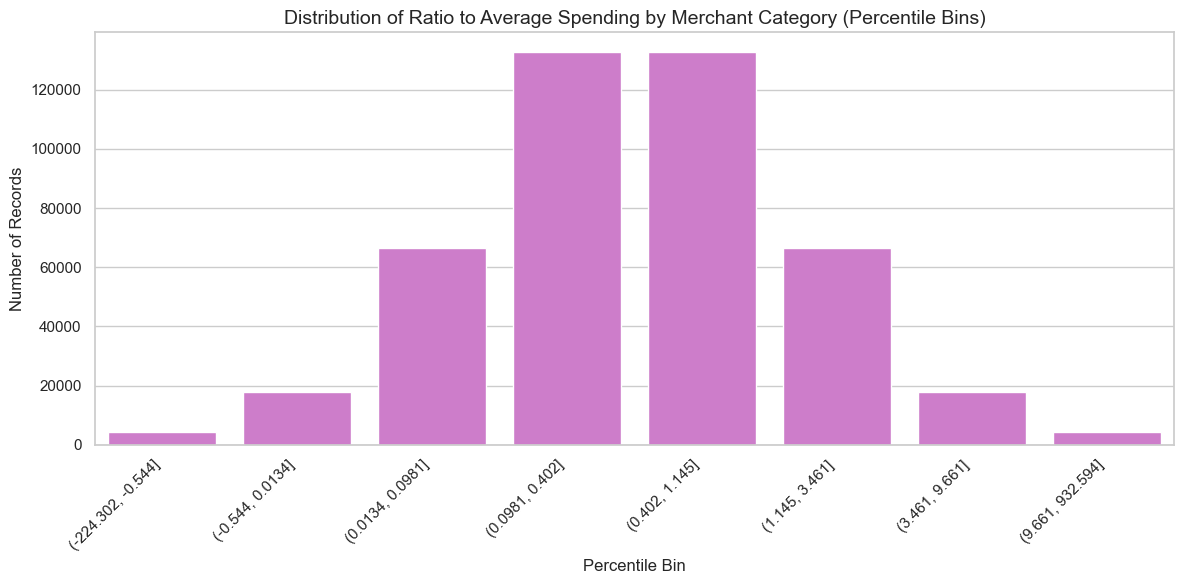

In [20]:
# Define variable and percentiles
var = 'ratio_category_avg_amount'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
feature_df_2[binned_var] = pd.qcut(
    feature_df_2[var],
    q=percentiles,
    duplicates='drop'
)

# Get bin interval labels as strings
xticklabels = feature_df_2[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_2, color='orchid')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Average Spending by Merchant Category (Percentile Bins)', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [21]:
# Define high anomaly threshold
threshold = 9.661

# Flag anomalies where the ratio exceeds the threshold
feature_df_2['Anomaly_ratio_category_avg_amount'] = (
    feature_df_2['ratio_category_avg_amount'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_2['Anomaly_ratio_category_avg_amount'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4425


In [22]:
# View top anomalies
anomalies_f2 = feature_df_2[
    feature_df_2['Anomaly_ratio_category_avg_amount'] == 1
][[
    'Merchant_Category', 'Amount', 'avg_category_amount', 'ratio_category_avg_amount'
]].sort_values('ratio_category_avg_amount', ascending=False)

anomalies_f2.head()

,Merchant_Category,Amount,avg_category_amount,ratio_category_avg_amount
251918,"COMMERCIAL EQUIPMENT, NOT ELSEWHERE CLASSIFIED",1089180.00,1167.903672,932.594037
365832,"COMMERCIAL EQUIPMENT, NOT ELSEWHERE CLASSIFIED",855343.00,1167.903672,732.374613
218925,OTHER FEES,1903858.37,3306.516456,575.789776
212076,OTHER FEES,1750379.98,3306.516456,529.372832
400124,CHEMICALS AND ALLIED PRODUCTS NOT ELSEWHERE CL...,348053.75,709.606306,490.488525


The feature 2, Ratio to Average Spending by Merchant Category, captures abnormal transactions relative to typical spending for that type of good or service. It provides crucial context for evaluating whether a purchase is reasonable. This ratio helps spot outlier spending behaviors that raw amounts alone would miss, such as large expenses hidden in typically low-cost categories.

### Feature 3: Ratio to Average Spending by Description (ratio_description_avg_amount)

Definition:

This feature divides the transaction amount by the historical average amount spent on transactions sharing the same purchase Description across the entire dataset.

In [23]:
# Compute average spending per description
description_avg = (
    df.groupby('Description')['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_description_amount'})
)

# Merge the average back into the main dataset
feature_df_3 = df.merge(
    description_avg,
    on='Description',
    how='left'
)

# Calculate the ratio safely
feature_df_3['ratio_description_avg_amount'] = np.where(
    feature_df_3['avg_description_amount'] == 0,
    0,
    feature_df_3['Amount'] / feature_df_3['avg_description_amount']
)

# Preview the new feature
feature_df_3[['Description', 'Amount', 'avg_description_amount', 'ratio_description_avg_amount']].head()

,Description,Amount,avg_description_amount,ratio_description_avg_amount
0,GENERAL PURCHASE,890.00,482.020412,1.846395
1,ROOM CHARGES,368.96,345.706024,1.067265
2,GENERAL PURCHASE,165.82,482.020412,0.344010
3,GENERAL PURCHASE,96.39,482.020412,0.199971
4,HAMMERMILL COPY PLUS COPY EA,125.96,126.436000,0.996235


In [24]:
# Summarize the new ratio feature
feature_df_3['ratio_description_avg_amount'].describe()

count    4.424580e+05
mean     9.988844e-01
std      1.830668e+14
min     -6.275203e+16
25%      1.347661e-01
50%      6.223803e-01
75%      1.000000e+00
max      6.275203e+16
Name: ratio_description_avg_amount, dtype: float64

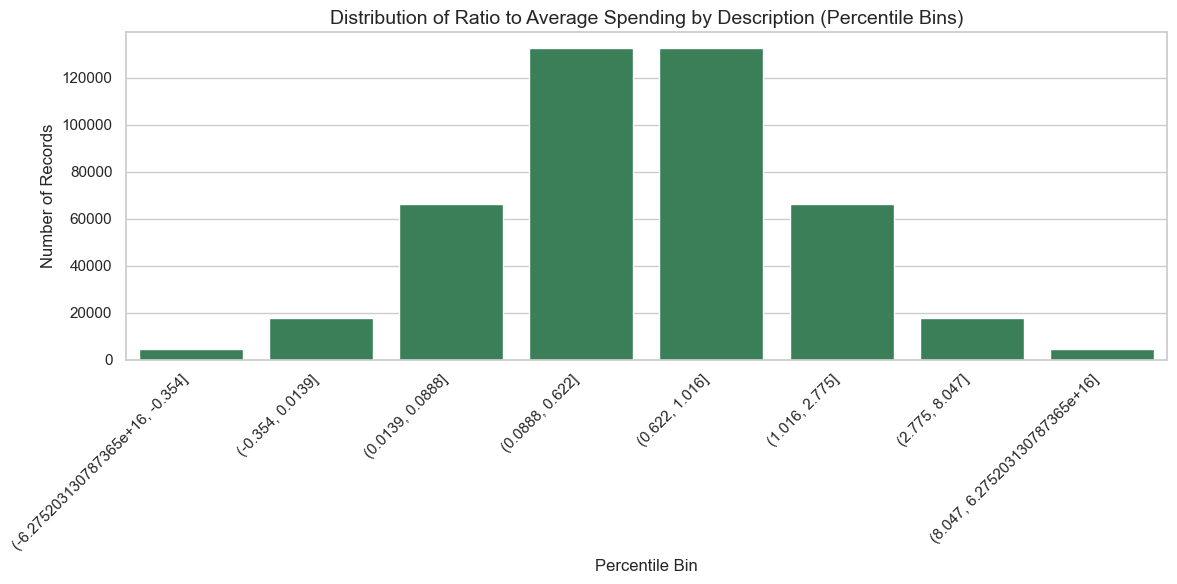

In [25]:
# Define variable and percentiles
var = 'ratio_description_avg_amount'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Cut into percentile bins
feature_df_3[binned_var] = pd.qcut(
    feature_df_3[var],
    q=percentiles,
    duplicates='drop'
)

# Get bin interval labels as strings
xticklabels = feature_df_3[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_3, color='seagreen')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Average Spending by Description (Percentile Bins)', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [26]:
# Define high anomaly threshold
threshold = 8.047

# Flag anomalies where the ratio exceeds the threshold
feature_df_3['Anomaly_ratio_description_avg_amount'] = (
    feature_df_3['ratio_description_avg_amount'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_3['Anomaly_ratio_description_avg_amount'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4425


In [27]:
# View top anomalies
anomalies_f3 = feature_df_3[
    feature_df_3['Anomaly_ratio_description_avg_amount'] == 1
][[
    'Description', 'Amount', 'avg_description_amount', 'ratio_description_avg_amount'
]].sort_values('ratio_description_avg_amount', ascending=False)

anomalies_f3.head()

,Description,Amount,avg_description_amount,ratio_description_avg_amount
299975,Coiled Air Hose1/2 In ID EA,111.47,1.776357e-15,6.275203e+16
365678,Adapter2 x 1-1/2 In250 EA,-547.20,-1.154632e-14,4.739173e+16
299974,Coiled Air Hose1/2 In ID EA,62.15,1.776357e-15,3.498734e+16
365680,Adapter2 x 1-1/2 In250 EA,-28.80,-1.154632e-14,2.494301e+15
218925,GENERAL PURCHASE,1903858.37,4.820204e+02,3.949746e+03


The feature 3, Ratio to Average Spending by Description, is valuable because it adapts anomaly detection to the unique spending context of different purchase types. It highlights transactions that are suspiciously large (or small) for a specific purpose, making it easier to detect fraud, errors, or policy breaches that raw dollar amounts would not reveal.

### Feature 4: Ratio to Average Spending by Agency (ratio_agency_avg_amount)

Defition:

This feature divides the transaction amount by the historical average amount spent by the same Agency_Name across the dataset.

In [28]:
# Calculate average spending per agency
agency_avg = (
    df.groupby('Agency_Name')['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_agency_amount'})
)

# Merge agency averages back into the main data
feature_df_4 = df.merge(
    agency_avg,
    on='Agency_Name',
    how='left'
)

# Calculate the ratio safely
feature_df_4['ratio_agency_avg_amount'] = np.where(
    feature_df_4['avg_agency_amount'] == 0,
    0,
    feature_df_4['Amount'] / feature_df_4['avg_agency_amount']
)

# Preview new feature
feature_df_4[['Agency_Name', 'Amount', 'avg_agency_amount', 'ratio_agency_avg_amount']].head()

,Agency_Name,Amount,avg_agency_amount,ratio_agency_avg_amount
0,OKLAHOMA STATE UNIVERSITY,890.00,291.209448,3.056220
1,OKLAHOMA STATE UNIVERSITY,368.96,291.209448,1.266992
2,OKLAHOMA STATE UNIVERSITY,165.82,291.209448,0.569418
3,OKLAHOMA STATE UNIVERSITY,96.39,291.209448,0.330999
4,OKLAHOMA STATE UNIVERSITY,125.96,291.209448,0.432541


In [29]:
# Summarize the new ratio feature
feature_df_4['ratio_agency_avg_amount'].describe()

count    442458.000000
mean          1.000000
std           9.887348
min        -127.708749
25%           0.087394
50%           0.289954
75%           0.927133
max        4521.244689
Name: ratio_agency_avg_amount, dtype: float64

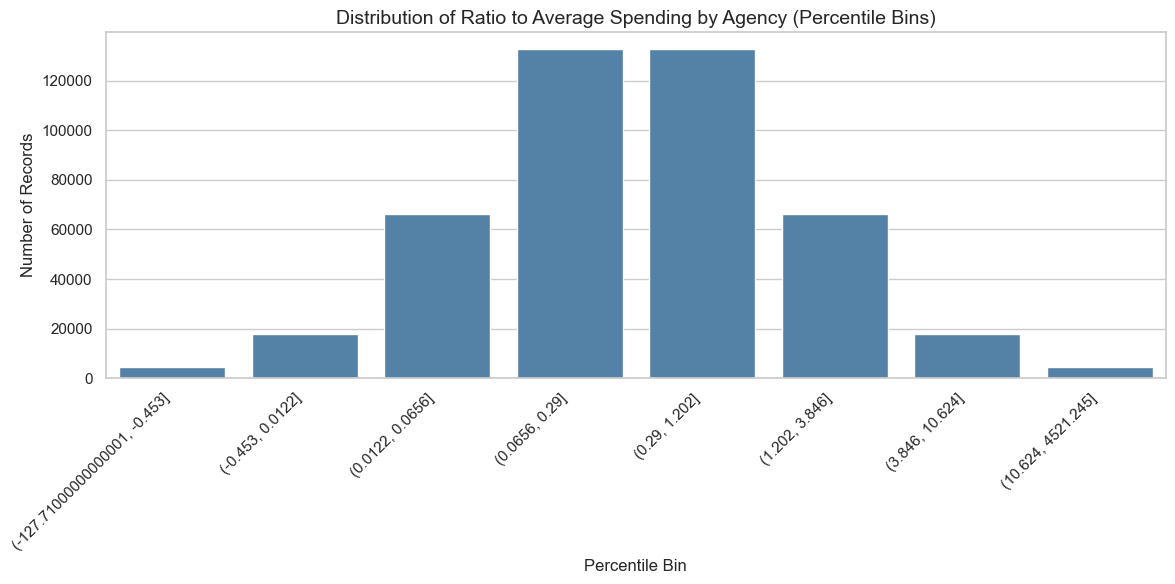

In [30]:
# Define variable and percentiles
var = 'ratio_agency_avg_amount'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_4[binned_var] = pd.qcut(
    feature_df_4[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare bin labels for plotting
xticklabels = feature_df_4[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_4, color='steelblue')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Average Spending by Agency (Percentile Bins)', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [31]:
# Define high anomaly threshold
threshold = 10.624

# Flag transactions exceeding the threshold
feature_df_4['Anomaly_ratio_agency_avg_amount'] = (
    feature_df_4['ratio_agency_avg_amount'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_4['Anomaly_ratio_agency_avg_amount'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4425


In [32]:
# Display top anomalies
anomalies_f4 = feature_df_4[
    feature_df_4['Anomaly_ratio_agency_avg_amount'] == 1
][[
    'Agency_Name', 'Amount', 'avg_agency_amount', 'ratio_agency_avg_amount'
]].sort_values('ratio_agency_avg_amount', ascending=False)

anomalies_f4.head()

,Agency_Name,Amount,avg_agency_amount,ratio_agency_avg_amount
218925,UNIV. OF OKLA. HEALTH SCIENCES CENTER,1903858.37,421.091646,4521.244689
212076,UNIV. OF OKLA. HEALTH SCIENCES CENTER,1750379.98,421.091646,4156.767285
251918,GRAND RIVER DAM AUTH.,1089180.00,2130.414238,511.252685
365832,GRAND RIVER DAM AUTH.,855343.00,2130.414238,401.491402
251488,GRAND RIVER DAM AUTH.,814934.76,2130.414238,382.524086


The feature 4, Ratio to Average Spending by Agency, is valuable because it places each transaction in the proper organizational context. It helps flag transactions that are disproportionate to an agency’s usual spending levels, enhancing anomaly detection by considering differences in agency size, mission, and spending patterns.

### Feature 5: Ratio to Average Spending by Day of Week (ratio_dow_avg_amount)

Definition: 

This feature divides the transaction amount by the average amount spent on the same day of the week across the dataset. It compares each transaction to typical spending levels on that weekday.

In [33]:
# Calculate average spending per Day_of_Week
dow_avg = (
    df.groupby('Day_of_Week')['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_dow_amount'})
)

# Merge average weekday spending back into the main dataset
feature_df_5 = df.merge(
    dow_avg,
    on='Day_of_Week',
    how='left'
)

# Calculate ratio safely
feature_df_5['ratio_dow_avg_amount'] = np.where(
    feature_df_5['avg_dow_amount'] == 0,
    0,
    feature_df_5['Amount'] / feature_df_5['avg_dow_amount']
)

# Preview result
feature_df_5[['Day_of_Week', 'Amount', 'avg_dow_amount', 'ratio_dow_avg_amount']].head()

,Day_of_Week,Amount,avg_dow_amount,ratio_dow_avg_amount
0,Tuesday,890.00,434.565270,2.048024
1,Tuesday,368.96,434.565270,0.849032
2,Monday,165.82,419.504502,0.395276
3,Tuesday,96.39,434.565270,0.221808
4,Tuesday,125.96,434.565270,0.289853


In [34]:
# Summarize the new ratio feature
feature_df_5['ratio_dow_avg_amount'].describe()

count    442458.000000
mean          1.000000
std          11.900835
min        -117.066777
25%           0.074731
50%           0.250815
75%           0.817506
max        4462.759807
Name: ratio_dow_avg_amount, dtype: float64

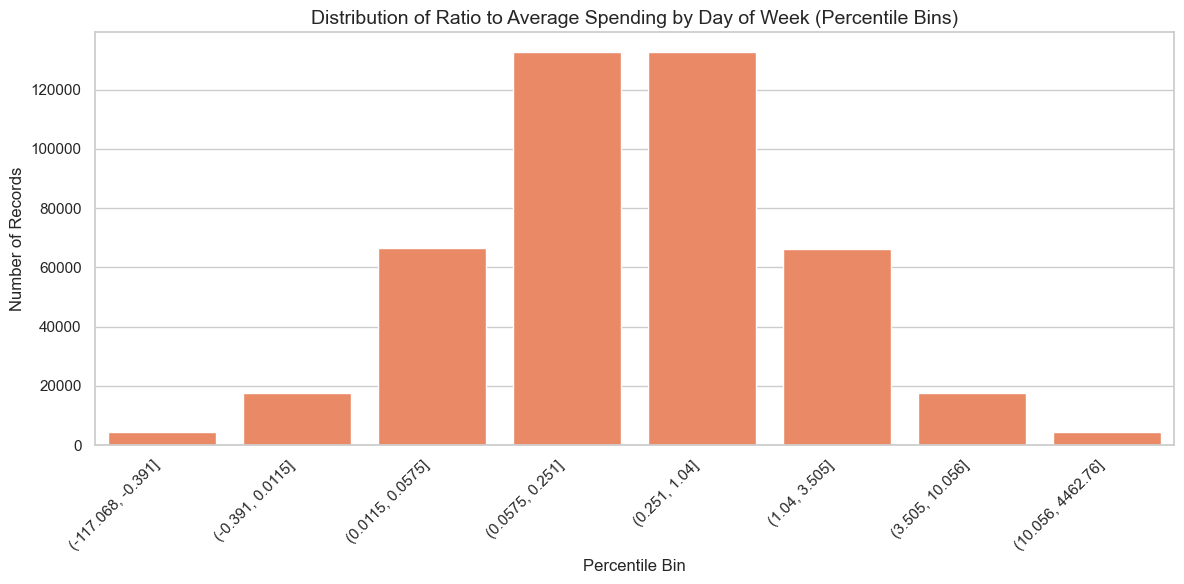

In [35]:
# Define variable and percentiles
var = 'ratio_dow_avg_amount'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_5[binned_var] = pd.qcut(
    feature_df_5[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare bin labels for plotting
xticklabels = feature_df_5[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_5, color='coral')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Average Spending by Day of Week (Percentile Bins)', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [36]:
# Define high anomaly threshold
threshold = 10.056

# Flag transactions exceeding the threshold
feature_df_5['Anomaly_ratio_dow_avg_amount'] = (
    feature_df_5['ratio_dow_avg_amount'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_5['Anomaly_ratio_dow_avg_amount'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4425


In [37]:
# Display top anomalies
anomalies_f5 = feature_df_5[
    feature_df_5['Anomaly_ratio_dow_avg_amount'] == 1
][[
    'Day_of_Week', 'Amount', 'avg_dow_amount', 'ratio_dow_avg_amount'
]].sort_values('ratio_dow_avg_amount', ascending=False)

anomalies_f5.head()

,Day_of_Week,Amount,avg_dow_amount,ratio_dow_avg_amount
218925,Wednesday,1903858.37,426.610092,4462.759807
212076,Friday,1750379.98,466.652521,3750.927938
251918,Friday,1089180.00,466.652521,2334.027890
251488,Thursday,814934.76,435.048559,1873.204138
365832,Friday,855343.00,466.652521,1832.933415


The feature 5, Ratio to Average Spending by Day of Week, is valuable because it recognizes that different days naturally exhibit different spending volumes. Transactions that deviate sharply from typical weekday norms may indicate errors, rushed purchases, or potential misuse. This feature provides context for temporal spending patterns, enhancing anomaly detection’s precision.

### Feature 6: Ratio to Average Spending by YearMonth (ratio_ym_avg_amount)

Definition:

This feature divides each transaction’s amount by the average amount spent in the same Year-Month (e.g. 2023-05) across the entire dataset.

In [38]:
# Calculate average spending per Year_Month
ym_avg = (
    df.groupby('Year_Month')['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_ym_amount'})
)

# Merge monthly averages back into the data
feature_df_6 = df.merge(
    ym_avg,
    on='Year_Month',
    how='left'
)

# Compute the ratio safely
feature_df_6['ratio_ym_avg_amount'] = np.where(
    feature_df_6['avg_ym_amount'] == 0,
    0,
    feature_df_6['Amount'] / feature_df_6['avg_ym_amount']
)

# Preview new feature
feature_df_6[['Year_Month', 'Amount', 'avg_ym_amount', 'ratio_ym_avg_amount']].head()

,Year_Month,Amount,avg_ym_amount,ratio_ym_avg_amount
0,2013-07-01,890.00,419.18043,2.123191
1,2013-07-01,368.96,419.18043,0.880194
2,2013-07-01,165.82,419.18043,0.395581
3,2013-07-01,96.39,419.18043,0.229949
4,2013-07-01,125.96,419.18043,0.300491


In [39]:
# Summarize the ratio feature
feature_df_6['ratio_ym_avg_amount'].describe()

count    442458.000000
mean          1.000000
std          11.893246
min         -93.007688
25%           0.073801
50%           0.248726
75%           0.812234
max        4214.230893
Name: ratio_ym_avg_amount, dtype: float64

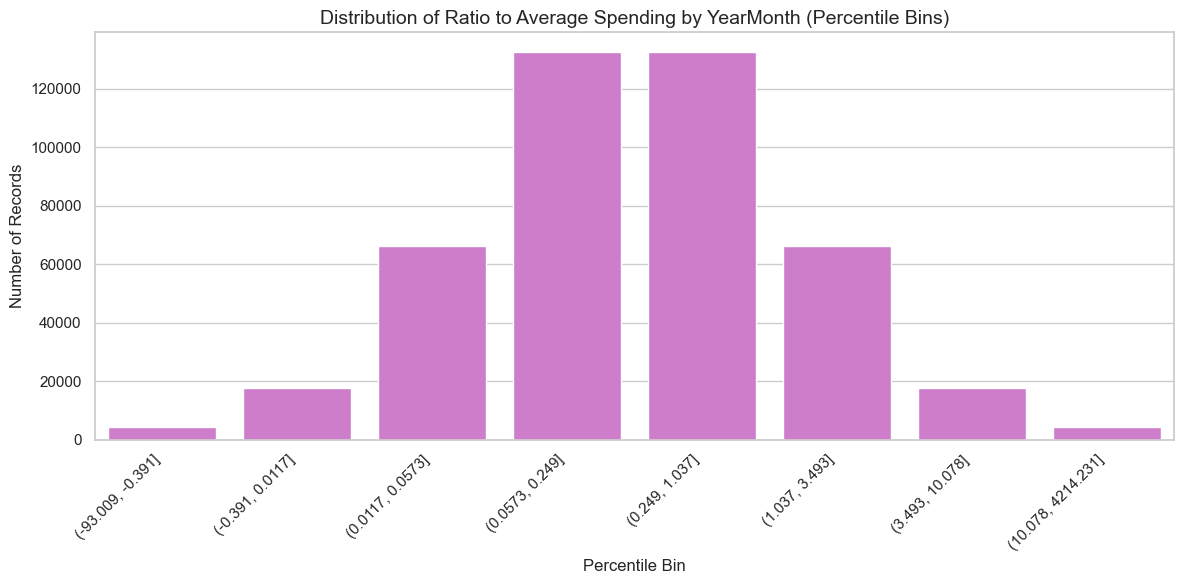

In [40]:
# Define variable and percentiles
var = 'ratio_ym_avg_amount'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create bins
feature_df_6[binned_var] = pd.qcut(
    feature_df_6[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare labels
xticklabels = feature_df_6[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_6, color='orchid')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Average Spending by YearMonth (Percentile Bins)', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [41]:
# Define high threshold
threshold = 5

# Flag anomalies
feature_df_6['Anomaly_ratio_ym_avg_amount'] = (
    feature_df_6['ratio_ym_avg_amount'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_6['Anomaly_ratio_ym_avg_amount'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 13875


In [42]:
# Preview anomalies
anomalies_f6 = feature_df_6[
    feature_df_6['Anomaly_ratio_ym_avg_amount'] == 1
][[
    'Year_Month', 'Amount', 'avg_ym_amount', 'ratio_ym_avg_amount'
]].sort_values('ratio_ym_avg_amount', ascending=False)

anomalies_f6.head()

,Year_Month,Amount,avg_ym_amount,ratio_ym_avg_amount
218925,2013-09-01,1903858.37,451.768880,4214.230893
212076,2013-08-01,1750379.98,455.041425,3846.638750
251918,2013-10-01,1089180.00,435.781619,2499.371136
251488,2013-10-01,814934.76,435.781619,1870.053083
365832,2014-03-01,855343.00,460.854807,1855.992358


The feature 6, Ratio to Average Spending by YearMonth, is valuable because it accounts for month-to-month budget cycles, seasonal events, and time-specific spending patterns. High spikes compared to the monthly average may indicate urgent projects, unexpected purchases, or potential misuse. This feature places transactions in their proper time context, enhancing anomaly detection’s precision.

### 4.2 Benchmark – Two Categories Average Spending Ratios

### Feature 7: Ratio to Average Spending by Agency and Merchant (ratio_agency_cat_mean)

Definition:

This feature divides the transaction amount by the average spending for the same combination of Agency and Merchant Category:

In [43]:
# Calculate average amount for each Agency + Merchant Category combination
agency_cat_avg = (
    df.groupby(['Agency_Name', 'Merchant_Category'])['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_agency_cat_amount'})
)

# Merge average back into original dataset
feature_df_7 = df.merge(
    agency_cat_avg,
    on=['Agency_Name', 'Merchant_Category'],
    how='left'
)

# Calculate the ratio, avoiding division by zero
feature_df_7['ratio_agency_cat_mean'] = np.where(
    feature_df_7['avg_agency_cat_amount'] == 0,
    0,
    feature_df_7['Amount'] / feature_df_7['avg_agency_cat_amount']
)

# Preview
feature_df_7[[
    'Agency_Name', 'Merchant_Category', 'Amount',
    'avg_agency_cat_amount', 'ratio_agency_cat_mean'
]].head()

,Agency_Name,Merchant_Category,Amount,avg_agency_cat_amount,ratio_agency_cat_mean
0,OKLAHOMA STATE UNIVERSITY,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,890.00,427.634060,2.081219
1,OKLAHOMA STATE UNIVERSITY,SHERATON,368.96,378.629890,0.974461
2,OKLAHOMA STATE UNIVERSITY,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,165.82,392.459376,0.422515
3,OKLAHOMA STATE UNIVERSITY,"GROCERY STORES,AND SUPERMARKETS",96.39,59.832149,1.611007
4,OKLAHOMA STATE UNIVERSITY,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",125.96,271.213133,0.464432


In [44]:
feature_df_7['ratio_agency_cat_mean'].describe()

count    442458.000000
mean          0.999724
std           7.225363
min       -2735.680000
25%           0.177145
50%           0.515301
75%           1.102916
max        2735.680000
Name: ratio_agency_cat_mean, dtype: float64

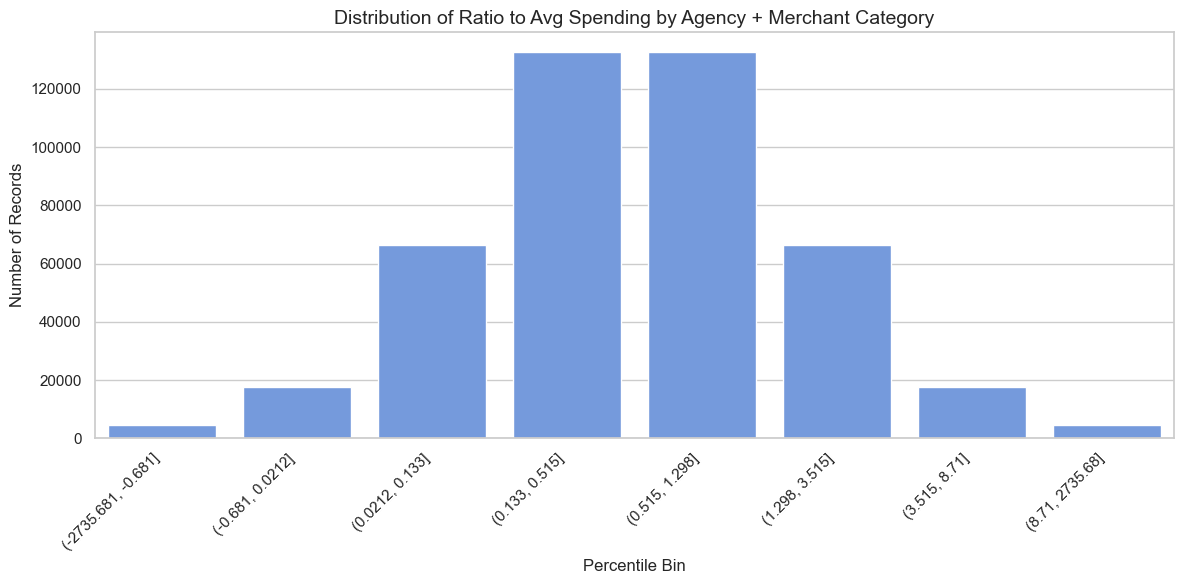

In [45]:
# Define variable and bins
var = 'ratio_agency_cat_mean'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_7[binned_var] = pd.qcut(
    feature_df_7[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare labels
xticklabels = feature_df_7[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_7, color='cornflowerblue')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Avg Spending by Agency + Merchant Category', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [46]:
# Define threshold
threshold = 8.71

# Flag anomalies
feature_df_7['Anomaly_ratio_agency_cat_mean'] = (
    feature_df_7['ratio_agency_cat_mean'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_7['Anomaly_ratio_agency_cat_mean'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4425


In [47]:
# Display top anomalies
anomalies_f7 = feature_df_7[
    feature_df_7['Anomaly_ratio_agency_cat_mean'] == 1
][[
    'Agency_Name', 'Merchant_Category', 'Amount',
    'avg_agency_cat_amount', 'ratio_agency_cat_mean'
]].sort_values('ratio_agency_cat_mean', ascending=False)

anomalies_f7.head()

,Agency_Name,Merchant_Category,Amount,avg_agency_cat_amount,ratio_agency_cat_mean
147691,COMM. ON CONSUMER CREDIT,SHERATON,512.94,0.187500,2735.680000
147634,COMM. ON CONSUMER CREDIT,SHERATON,170.98,0.187500,911.893333
147645,COMM. ON CONSUMER CREDIT,SHERATON,170.98,0.187500,911.893333
147648,COMM. ON CONSUMER CREDIT,SHERATON,170.98,0.187500,911.893333
285032,OKLAHOMA MILITARY DEPARTMENT,"STATIONERY,OFFICE AND SCHOOL SUPPLY STORES",43296.00,149.098537,290.385144


The feature 7, Ratio to Average Spending by Agency and Merchant, is powerful because it evaluates transactions in a highly specific context. A purchase might look normal compared to general averages but appear excessive for a particular agency’s usual dealings in that merchant category. This precise targeting makes it significantly easier to flag potential misuse, errors, or fraud.

### Feature 8: Ratio to Average Spending by Agency and Vendor (ratio_agency_vendor_mean)

Definition:

This feature divides each transaction’s amount by the average spending for the same combination of Agency and Vendor.

In [48]:
# Calculate average amount for each Agency + Vendor combination
agency_vendor_avg = (
    df.groupby(['Agency_Name', 'Vendor'])['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_agency_vendor_amount'})
)

# Merge average back into original dataset
feature_df_8 = df.merge(
    agency_vendor_avg,
    on=['Agency_Name', 'Vendor'],
    how='left'
)

# Calculate the ratio, avoiding divide-by-zero
feature_df_8['ratio_agency_vendor_mean'] = np.where(
    feature_df_8['avg_agency_vendor_amount'] == 0,
    0,
    feature_df_8['Amount'] / feature_df_8['avg_agency_vendor_amount']
)

# Preview
feature_df_8[[
    'Agency_Name', 'Vendor', 'Amount',
    'avg_agency_vendor_amount', 'ratio_agency_vendor_mean'
]].head()

,Agency_Name,Vendor,Amount,avg_agency_vendor_amount,ratio_agency_vendor_mean
0,OKLAHOMA STATE UNIVERSITY,NACAS,890.00,715.555556,1.243789
1,OKLAHOMA STATE UNIVERSITY,SHERATON HOTEL,368.96,471.909333,0.781845
2,OKLAHOMA STATE UNIVERSITY,SEARS.COM 9300,165.82,92.030833,1.801787
3,OKLAHOMA STATE UNIVERSITY,WAL-MART #0137,96.39,62.416879,1.544294
4,OKLAHOMA STATE UNIVERSITY,STAPLES DIRECT,125.96,143.682017,0.876658


In [49]:
feature_df_8['ratio_agency_vendor_mean'].describe()

count    4.424580e+05
mean     9.931041e-01
std      1.963144e+14
min     -6.944551e+16
25%      3.399096e-01
50%      9.543105e-01
75%      1.040700e+00
max      6.424385e+16
Name: ratio_agency_vendor_mean, dtype: float64

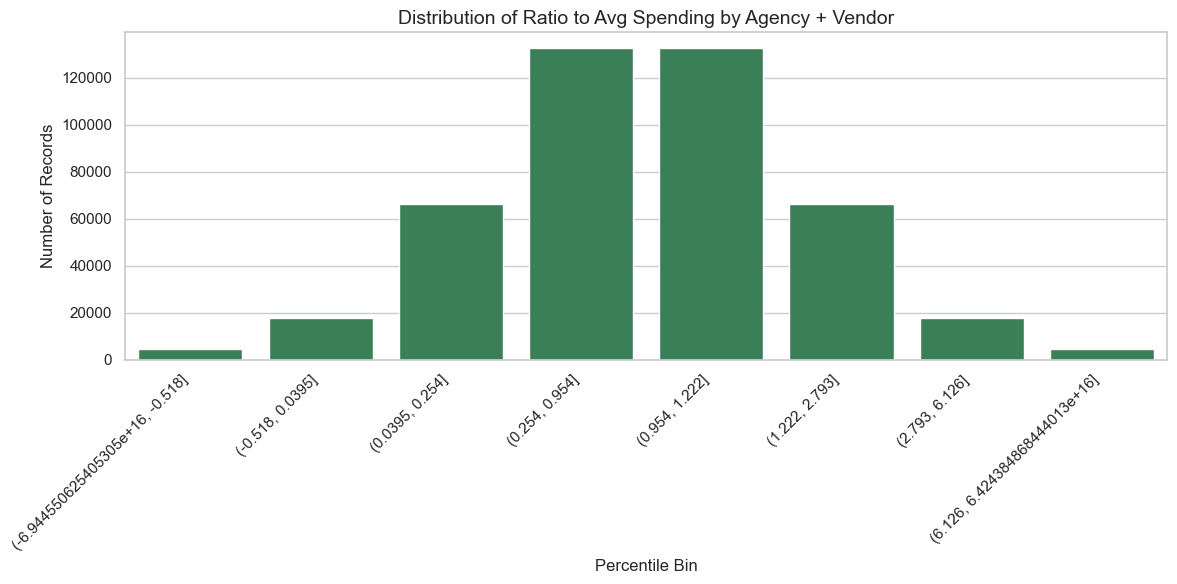

In [50]:
# Define variable and bins
var = 'ratio_agency_vendor_mean'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_8[binned_var] = pd.qcut(
    feature_df_8[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare labels
xticklabels = feature_df_8[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_8, color='seagreen')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Avg Spending by Agency + Vendor', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [51]:
# Define threshold
threshold = 5

# Flag anomalies
feature_df_8['Anomaly_ratio_agency_vendor_mean'] = (
    feature_df_8['ratio_agency_vendor_mean'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_8['Anomaly_ratio_agency_vendor_mean'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 6802


In [52]:
# Display top anomalies
anomalies_f8 = feature_df_8[
    feature_df_8['Anomaly_ratio_agency_vendor_mean'] == 1
][[
    'Agency_Name', 'Vendor', 'Amount',
    'avg_agency_vendor_amount', 'ratio_agency_vendor_mean'
]].sort_values('ratio_agency_vendor_mean', ascending=False)

anomalies_f8.head()

,Agency_Name,Vendor,Amount,avg_agency_vendor_amount,ratio_agency_vendor_mean
382184,OKLAHOMA STATE UNIVERSITY,COLVIN CENTER,76.08,1.184238e-15,6.424385e+16
311657,OKLA. PANHANDLE STATE UNIV.,TRAVRES HotelPlanner,769.32,1.421085e-14,5.413608e+16
18338,OKLAHOMA STATE UNIVERSITY,TARGET.COM,2393.88,7.579123e-14,3.158519e+16
5133,OKLAHOMA STATE UNIVERSITY,TARGET.COM,2382.88,7.579123e-14,3.144005e+16
21443,OKLAHOMA STATE UNIVERSITY,TRACTOR SUPPLY CO #5509,-56.13,-4.736952e-15,1.184939e+16


The feature 8, Ratio to Average Spending by Agency and Vendor, is valuable because it localizes anomaly detection to precise agency–vendor relationships. A payment may appear normal when compared to a vendor’s overall business but be excessive for a specific agency’s typical spending with that vendor. This fine-grained perspective helps catch misuse, errors, or fraud that broader averages might miss. 

### Feature 9: Ratio to Average Spending by Agency and Description (ratio_agency_description_mean)

Definition:

This feature divides each transaction amount by the average amount for the same Agency and Description combination.

In [53]:
# Calculate average amount for each Agency + Description combination
agency_desc_avg = (
    df.groupby(['Agency_Name', 'Description'])['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_agency_description_amount'})
)

# Merge averages back into the original dataset
feature_df_9 = df.merge(
    agency_desc_avg,
    on=['Agency_Name', 'Description'],
    how='left'
)

# Calculate the ratio, avoiding divide-by-zero
feature_df_9['ratio_agency_description_mean'] = np.where(
    feature_df_9['avg_agency_description_amount'] == 0,
    0,
    feature_df_9['Amount'] / feature_df_9['avg_agency_description_amount']
)

# Preview
feature_df_9[[
    'Agency_Name', 'Description', 'Amount',
    'avg_agency_description_amount', 'ratio_agency_description_mean'
]].head()

,Agency_Name,Description,Amount,avg_agency_description_amount,ratio_agency_description_mean
0,OKLAHOMA STATE UNIVERSITY,GENERAL PURCHASE,890.00,317.237258,2.805471
1,OKLAHOMA STATE UNIVERSITY,ROOM CHARGES,368.96,385.163806,0.957930
2,OKLAHOMA STATE UNIVERSITY,GENERAL PURCHASE,165.82,317.237258,0.522700
3,OKLAHOMA STATE UNIVERSITY,GENERAL PURCHASE,96.39,317.237258,0.303842
4,OKLAHOMA STATE UNIVERSITY,HAMMERMILL COPY PLUS COPY EA,125.96,70.570000,1.784894


In [54]:
feature_df_9['ratio_agency_description_mean'].describe()

count    4.424580e+05
mean     9.987131e-01
std      1.830668e+14
min     -6.275203e+16
25%      1.612732e-01
50%      7.449663e-01
75%      1.000000e+00
max      6.275203e+16
Name: ratio_agency_description_mean, dtype: float64

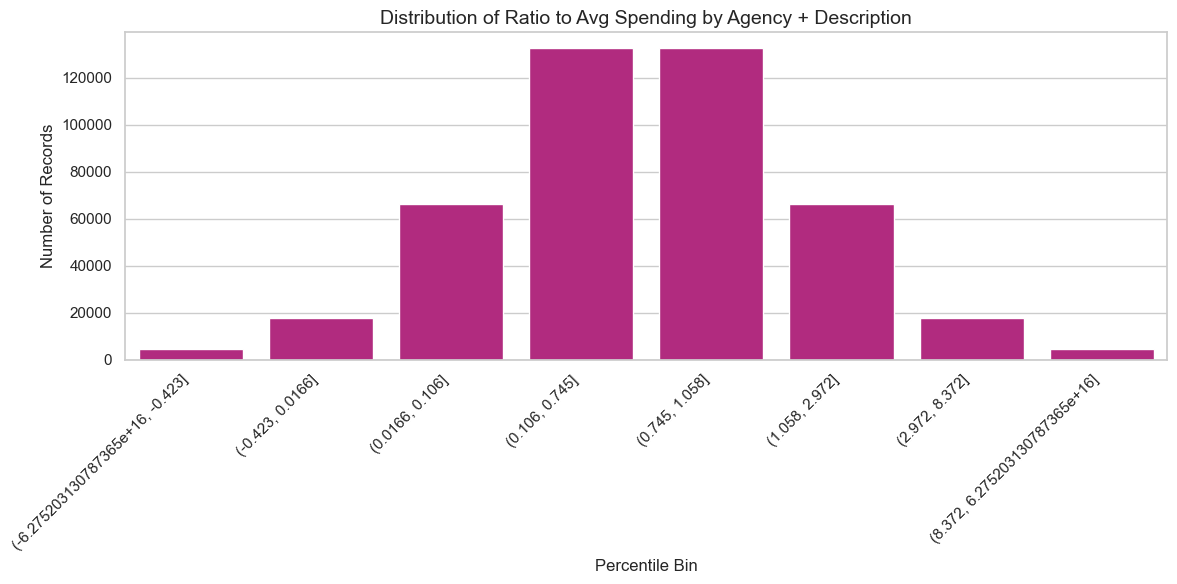

In [55]:
# Define variable and bins
var = 'ratio_agency_description_mean'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_9[binned_var] = pd.qcut(
    feature_df_9[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare labels
xticklabels = feature_df_9[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_9, color='mediumvioletred')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Avg Spending by Agency + Description', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [56]:
# Define threshold
threshold = 8.372

# Flag anomalies
feature_df_9['Anomaly_ratio_agency_description_mean'] = (
    feature_df_9['ratio_agency_description_mean'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_9['Anomaly_ratio_agency_description_mean'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4426


In [57]:
# Display top anomalies
anomalies_f9 = feature_df_9[
    feature_df_9['Anomaly_ratio_agency_description_mean'] == 1
][[
    'Agency_Name', 'Description', 'Amount',
    'avg_agency_description_amount', 'ratio_agency_description_mean'
]].sort_values('ratio_agency_description_mean', ascending=False)

anomalies_f9.head()

,Agency_Name,Description,Amount,avg_agency_description_amount,ratio_agency_description_mean
299975,DEPARTMENT OF WILDLIFE CONSERVATION,Coiled Air Hose1/2 In ID EA,111.47,1.776357e-15,6.275203e+16
365678,GRAND RIVER DAM AUTH.,Adapter2 x 1-1/2 In250 EA,-547.20,-1.154632e-14,4.739173e+16
299974,DEPARTMENT OF WILDLIFE CONSERVATION,Coiled Air Hose1/2 In ID EA,62.15,1.776357e-15,3.498734e+16
365680,GRAND RIVER DAM AUTH.,Adapter2 x 1-1/2 In250 EA,-28.80,-1.154632e-14,2.494301e+15
218925,UNIV. OF OKLA. HEALTH SCIENCES CENTER,GENERAL PURCHASE,1903858.37,5.368581e+02,3.546297e+03


The feature 9, Ratio to Average Spending by Agency and Description, is valuable because it detects overspending tied to the purpose of expenditure. A charge might be normal for an agency overall but suspiciously high for a particular description like “Office Supplies.” By isolating transactions that diverge from agency-specific spending norms for each description, this ratio helps pinpoint potential misuse, errors, or fraud.

### Feature 10: Ratio to Average Spending by Agency and Day of Week (ratio_agency_weekday_mean)

Definition:

This feature divides each transaction amount by the average amount for the same agency and day of the week.

In [58]:
# Compute average amount for each Agency + Day_of_Week
agency_weekday_avg = (
    df.groupby(['Agency_Name', 'Day_of_Week'])['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_agency_weekday_amount'})
)

# Merge averages back into the original dataset
feature_df_10 = df.merge(
    agency_weekday_avg,
    on=['Agency_Name', 'Day_of_Week'],
    how='left'
)

# Calculate the ratio, avoiding divide-by-zero
feature_df_10['ratio_agency_weekday_mean'] = np.where(
    feature_df_10['avg_agency_weekday_amount'] == 0,
    0,
    feature_df_10['Amount'] / feature_df_10['avg_agency_weekday_amount']
)

# Preview
feature_df_10[[
    'Agency_Name', 'Day_of_Week', 'Amount',
    'avg_agency_weekday_amount', 'ratio_agency_weekday_mean'
]].head()

,Agency_Name,Day_of_Week,Amount,avg_agency_weekday_amount,ratio_agency_weekday_mean
0,OKLAHOMA STATE UNIVERSITY,Tuesday,890.00,297.991021,2.986667
1,OKLAHOMA STATE UNIVERSITY,Tuesday,368.96,297.991021,1.238158
2,OKLAHOMA STATE UNIVERSITY,Monday,165.82,288.672464,0.574423
3,OKLAHOMA STATE UNIVERSITY,Tuesday,96.39,297.991021,0.323466
4,OKLAHOMA STATE UNIVERSITY,Tuesday,125.96,297.991021,0.422697


In [59]:
feature_df_10['ratio_agency_weekday_mean'].describe()

count    442458.000000
mean          1.000000
std           8.257731
min        -124.213896
25%           0.088130
50%           0.294874
75%           0.942231
max        3644.668709
Name: ratio_agency_weekday_mean, dtype: float64

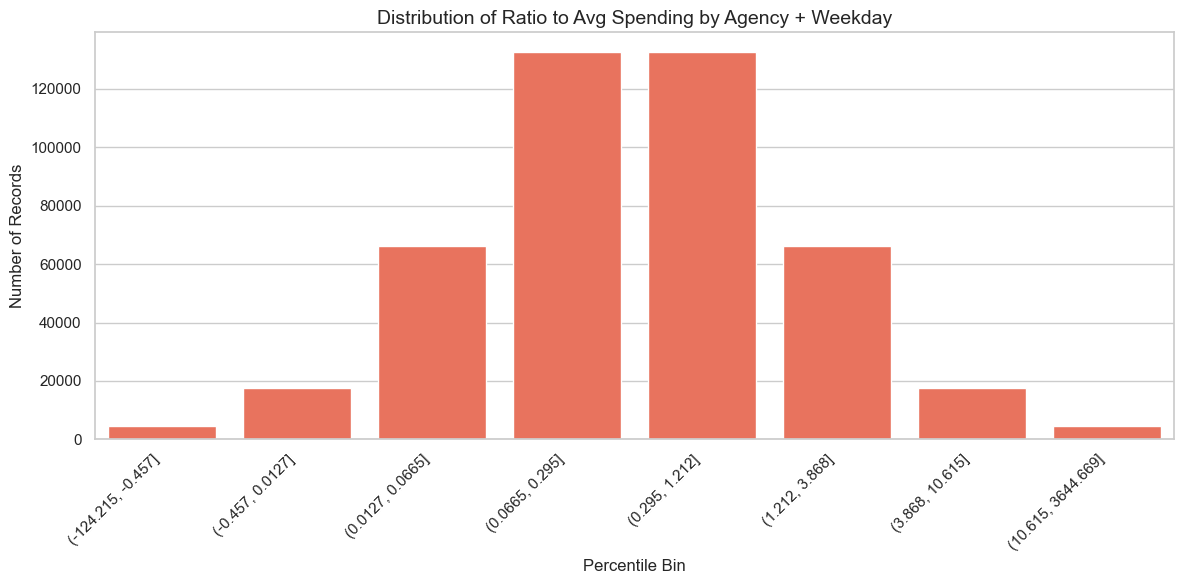

In [60]:
# Define variable and bins
var = 'ratio_agency_weekday_mean'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Bin into quantiles
feature_df_10[binned_var] = pd.qcut(
    feature_df_10[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare bin labels
xticklabels = feature_df_10[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_10, color='tomato')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Avg Spending by Agency + Weekday', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [61]:
# Define anomaly threshold
threshold = 10.615

# Flag anomalies
feature_df_10['Anomaly_ratio_agency_weekday_mean'] = (
    feature_df_10['ratio_agency_weekday_mean'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_10['Anomaly_ratio_agency_weekday_mean'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4425


In [62]:
# Show anomalies
anomalies_f10 = feature_df_10[
    feature_df_10['Anomaly_ratio_agency_weekday_mean'] == 1
][[
    'Agency_Name', 'Day_of_Week', 'Amount',
    'avg_agency_weekday_amount', 'ratio_agency_weekday_mean'
]].sort_values('ratio_agency_weekday_mean', ascending=False)

anomalies_f10.head()

,Agency_Name,Day_of_Week,Amount,avg_agency_weekday_amount,ratio_agency_weekday_mean
218925,UNIV. OF OKLA. HEALTH SCIENCES CENTER,Wednesday,1903858.37,522.368018,3644.668709
212076,UNIV. OF OKLA. HEALTH SCIENCES CENTER,Friday,1750379.98,510.604960,3428.051267
251488,GRAND RIVER DAM AUTH.,Thursday,814934.76,2243.798081,363.194339
251918,GRAND RIVER DAM AUTH.,Friday,1089180.00,3044.512982,357.751800
169572,UNIVERSITY OF OKLAHOMA,Thursday,114203.17,336.033256,339.856749


The feature 10, Ratio to Average Spending by Agency and Day of Week, is valuable because it spots transactions that break typical weekday patterns. Certain agencies spend predictably on specific days, so unusually large transactions on “quiet” days may indicate errors, rushed approvals, or fraudulent activity. This feature enables anomaly detection with both organizational and temporal context.

### Feature 11: Ratio to Average Spending by Merchant Category + Vendor (ratio_category_vendor_mean)

Definition:

This feature divides each transaction amount by the average amount for the same merchant category and vendor.

In [63]:
# Calculate average spending for each Merchant Category + Vendor
category_vendor_avg = (
    df.groupby(['Merchant_Category', 'Vendor'])['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_category_vendor_amount'})
)

# Merge averages back into the original data
feature_df_11 = df.merge(
    category_vendor_avg,
    on=['Merchant_Category', 'Vendor'],
    how='left'
)

# Compute the ratio, handling divide-by-zero safely
feature_df_11['ratio_category_vendor_mean'] = np.where(
    feature_df_11['avg_category_vendor_amount'] == 0,
    0,
    feature_df_11['Amount'] / feature_df_11['avg_category_vendor_amount']
)

# Preview
feature_df_11[[
    'Merchant_Category', 'Vendor', 'Amount',
    'avg_category_vendor_amount', 'ratio_category_vendor_mean'
]].head()

,Merchant_Category,Vendor,Amount,avg_category_vendor_amount,ratio_category_vendor_mean
0,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,NACAS,890.00,715.555556,1.243789
1,SHERATON,SHERATON HOTEL,368.96,214.383270,1.721030
2,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,SEARS.COM 9300,165.82,163.750339,1.012639
3,"GROCERY STORES,AND SUPERMARKETS",WAL-MART #0137,96.39,62.405600,1.544573
4,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",STAPLES DIRECT,125.96,144.875697,0.869435


In [64]:
feature_df_11['ratio_category_vendor_mean'].describe()

count    4.424580e+05
mean     9.940908e-01
std      9.397680e+13
min     -1.804536e+16
25%      2.768610e-01
50%      7.933907e-01
75%      1.025641e+00
max      5.413608e+16
Name: ratio_category_vendor_mean, dtype: float64

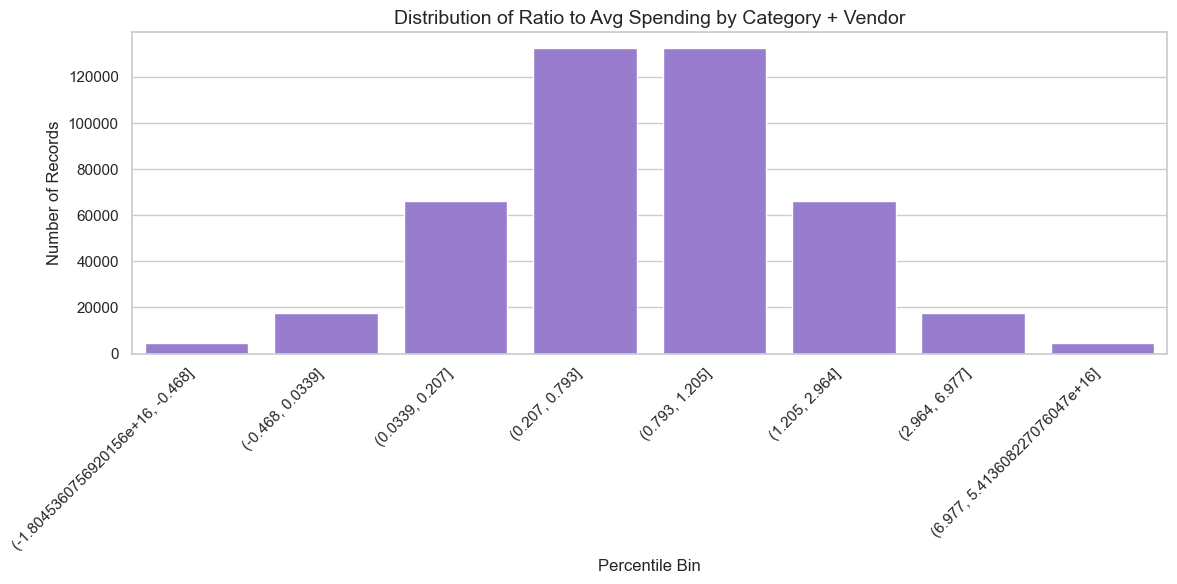

In [65]:
# Define variable and bins
var = 'ratio_category_vendor_mean'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_11[binned_var] = pd.qcut(
    feature_df_11[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare bin labels
xticklabels = feature_df_11[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_11, color='mediumpurple')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Avg Spending by Category + Vendor', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [66]:
# Define anomaly threshold
threshold = 5

# Flag anomalies
feature_df_11['Anomaly_ratio_category_vendor_mean'] = (
    feature_df_11['ratio_category_vendor_mean'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_11['Anomaly_ratio_category_vendor_mean'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 8416


In [67]:
# Preview Anomalies
anomalies_f11 = feature_df_11[
    feature_df_11['Anomaly_ratio_category_vendor_mean'] == 1
][[
    'Merchant_Category', 'Vendor', 'Amount',
    'avg_category_vendor_amount', 'ratio_category_vendor_mean'
]].sort_values('ratio_category_vendor_mean', ascending=False)

anomalies_f11.head()

,Merchant_Category,Vendor,Amount,avg_category_vendor_amount,ratio_category_vendor_mean
311657,TRAVEL AGENCIES,TRAVRES HotelPlanner,769.32,1.421085e-14,5.413608e+16
422221,COMPUTER NETWORK/INFORMATION SERVICES,GODADDY.COM CANADA,6.65,1.000000e-02,6.650000e+02
384436,MISCELLANEOUS AND SPECIALTY RETAIL STORES,BLUEBYTE TRADING LLC,1882.02,2.840000e+00,6.626831e+02
3659,"STATIONERY,OFFICE AND SCHOOL SUPPLY STORES",OFFICE DEPOT #47,-299.98,-6.877778e-01,4.361583e+02
80683,INDUSTRIAL SUPPLIES NOT ELSEWHERE CLASSIFIED,WW GRAINGER,96190.38,4.214489e+02,2.282373e+02


The Feature 11, Ratio to Average Spending by Merchant Category and Vendor, is valuable because it exposes transactions that break the normal vendor-category relationship. A merchant might bill average amounts for general purchases but spike prices within specific categories like “Electronics.” Benchmarking by both category and vendor offers a more precise lens for anomaly detection, catching subtle patterns that single-variable analysis might miss.

### Feature 12: Ratio to Average Spending by Merchant Category and Day of Week (ratio_category_dow_mean)

Definition:

This feature divides each transaction amount by the average amount for transactions in the same merchant category on the same day of the week.

In [68]:
# Calculate average spending for each Merchant Category + Day of Week
category_dow_avg = (
    df.groupby(['Merchant_Category', 'Day_of_Week'])['Amount']
    .mean()
    .reset_index()
    .rename(columns={'Amount': 'avg_category_dow_amount'})
)

# Merge averages back into original data
feature_df_12 = df.merge(
    category_dow_avg,
    on=['Merchant_Category', 'Day_of_Week'],
    how='left'
)

# Compute the ratio, avoiding divide-by-zero
feature_df_12['ratio_category_dow_mean'] = np.where(
    feature_df_12['avg_category_dow_amount'] == 0,
    0,
    feature_df_12['Amount'] / feature_df_12['avg_category_dow_amount']
)

# Preview
feature_df_12[[
    'Merchant_Category', 'Day_of_Week', 'Amount',
    'avg_category_dow_amount', 'ratio_category_dow_mean'
]].head()

,Merchant_Category,Day_of_Week,Amount,avg_category_dow_amount,ratio_category_dow_mean
0,CHARITABLE AND SOCIAL SERVICE ORGANIZATIONS,Tuesday,890.00,433.363514,2.053703
1,SHERATON,Tuesday,368.96,427.605377,0.862852
2,DIRCT MARKETING/DIRCT MARKETERS--NOT ELSEWHERE...,Monday,165.82,732.642798,0.226331
3,"GROCERY STORES,AND SUPERMARKETS",Tuesday,96.39,75.023408,1.284799
4,"STATIONERY, OFFICE SUPPLIES, PRINTING AND WRIT...",Tuesday,125.96,210.278002,0.599017


In [69]:
feature_df_12['ratio_category_dow_mean'].describe()

count    442458.000000
mean          0.999962
std           3.714262
min        -278.689542
25%           0.137470
50%           0.414735
75%           0.962322
max         430.090217
Name: ratio_category_dow_mean, dtype: float64

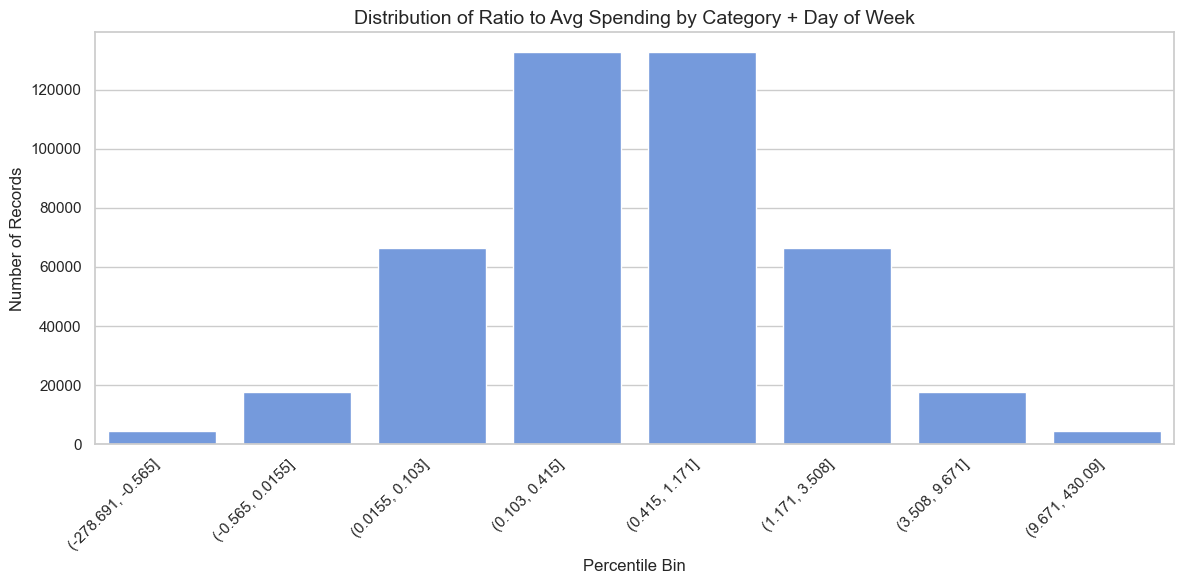

In [70]:
# Define variable and bins
var = 'ratio_category_dow_mean'
binned_var = var + '_D'
percentiles = [0, 0.01, 0.05, 0.2, 0.5, 0.8, 0.95, 0.99, 1]

# Create percentile bins
feature_df_12[binned_var] = pd.qcut(
    feature_df_12[var],
    q=percentiles,
    duplicates='drop'
)

# Prepare bin labels
xticklabels = feature_df_12[binned_var].cat.categories.astype(str).tolist()

# Plot
plt.figure(figsize=(12, 6))
ax = sns.countplot(x=binned_var, data=feature_df_12, color='cornflowerblue')
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(xticklabels, rotation=45, ha='right')
plt.title('Distribution of Ratio to Avg Spending by Category + Day of Week', fontsize=14)
plt.xlabel('Percentile Bin')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

In [71]:
# Define anomaly threshold
threshold = 9.671

# Flag anomalies
feature_df_12['Anomaly_ratio_category_dow_mean'] = (
    feature_df_12['ratio_category_dow_mean'] > threshold
).astype(int)

# Count anomalies
num_anomalies = feature_df_12['Anomaly_ratio_category_dow_mean'].sum()
print(f"Number of anomalies detected: {num_anomalies}")

Number of anomalies detected: 4424


In [72]:
anomalies_f12 = feature_df_12[
    feature_df_12['Anomaly_ratio_category_dow_mean'] == 1
][[
    'Merchant_Category', 'Day_of_Week', 'Amount',
    'avg_category_dow_amount', 'ratio_category_dow_mean'
]].sort_values('ratio_category_dow_mean', ascending=False)

anomalies_f12.head()

,Merchant_Category,Day_of_Week,Amount,avg_category_dow_amount,ratio_category_dow_mean
251488,"COMPUTERS, COMPUTER PERIPHERAL EQUIPMENT, SOFT...",Thursday,814934.76,1894.799573,430.090217
251918,"COMMERCIAL EQUIPMENT, NOT ELSEWHERE CLASSIFIED",Friday,1089180.00,2559.498646,425.544277
68603,GOVERNMENT SERVICES--NOT ELSEWHERE CLASSIFIED,Tuesday,183367.93,502.856065,364.652915
367490,"UTILITIES - ELECTRIC,GAS,WATER,SANITARY",Thursday,271761.09,776.001455,350.206934
367084,"UTILITIES - ELECTRIC,GAS,WATER,SANITARY",Tuesday,234017.52,684.732125,341.765066


The feature 12, Ratio to Average Spending by Merchant Category and Day of Week, is valuable because it captures time-sensitive spending norms within specific categories. Many government or corporate purchasing activities vary by weekday (e.g., bulk orders on Mondays, travel on Fridays). Comparing each transaction to its typical weekday-category level helps isolate unusual peaks or outlier behavior—suitable for anomaly detection.

### 4.3 Summary of the Engineered Ratio Features

In this feature engineering phase, we developed 12 ratio-based features to detect anomalies in purchasing behavior. These features systematically compare each transaction’s amount against meaningful benchmarks, capturing how much higher or lower it is relative to typical spending patterns.

Benchmarks by Single Category (Features 1–6):
- Feature 1: Ratio to Average Spending by Vendor
- Feature 2: Ratio to Average Spending by Merchant Category
- Feature 3: Ratio to Average Spending by Description
- Feature 4: Ratio to Average Spending by Agency
- Feature 5: Ratio to Average Spending by Day of Week
- Feature 6: Ratio to Average Spending by YearMonth

Benchmarks by Two Categories (Features 7–12):
- Feature 7: Ratio to Average Spending by Agency + Merchant Category
- Feature 8: Ratio to Average Spending by Agency + Vendor
- Feature 9: Ratio to Average Spending by Agency + Description
- Feature 10: Ratio to Average Spending by Agency + Day of Week
- Feature 11: Ratio to Average Spending by Merchant Category + Vendor
- Feature 12: Ratio to Average Spending by Merchant Category + Day of Week

These features together create a rich set of signals that help flag transactions deviating from typical behavior patterns, forming a strong foundation for subsequent anomaly detection or modeling efforts.

### 5. Histogram-based Outlier Score (HBOS)

In [75]:
#!pip install pyod
#!pip install combo

In [76]:
from pyod.models.hbos import HBOS
from pyod.models.combination import average
from pyod.utils.utility import standardizer
from pyod.utils.data import generate_data
from sklearn.model_selection import train_test_split

Prepare dataset for modeling

In [78]:
# Define the feature column names
feature_names = [
    'ratio_vendor_avg_amount',
    'ratio_category_avg_amount',
    'ratio_description_avg_amount',
    'ratio_agency_avg_amount',
    'ratio_dow_avg_amount',
    'ratio_ym_avg_amount',
    'ratio_agency_cat_mean',
    'ratio_agency_vendor_mean',
    'ratio_agency_description_mean',
    'ratio_agency_weekday_mean',
    'ratio_category_vendor_mean',
    'ratio_category_dow_mean'
]

# Extract each feature column
feature_series_list = []

for i in range(1, 13):
    df_name = f"feature_df_{i}"
    feature_name = feature_names[i-1]

    # extract the feature column as a Series
    feature_series = globals()[df_name][feature_name].reset_index(drop=True)
    feature_series_list.append(feature_series)

# Combine all Series into a single DataFrame
combined_feature_df = pd.concat(feature_series_list, axis=1)

# Set proper column names
combined_feature_df.columns = feature_names

# Check the shape
print(combined_feature_df.shape)
combined_feature_df.head()

(442458, 12)


,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean
0,1.243789,1.853968,1.846395,3.056220,2.048024,2.123191,2.081219,1.243789,2.805471,2.986667,1.243789,2.053703
1,1.721030,0.948063,1.067265,1.266992,0.849032,0.880194,0.974461,0.781845,0.957930,1.238158,1.721030,0.862852
2,1.012639,0.245108,0.344010,0.569418,0.395276,0.395581,0.422515,1.801787,0.522700,0.574423,1.012639,0.226331
3,1.544573,1.300424,0.199971,0.330999,0.221808,0.229949,1.611007,1.544294,0.303842,0.323466,1.544573,1.284799
4,0.869435,0.614693,0.996235,0.432541,0.289853,0.300491,0.464432,0.876658,1.784894,0.422697,0.869435,0.599017


### Step 1: Build the Model

In [132]:
# Confirm your real feature names
feature_list = list(combined_feature_df.columns)
print("Feature list:", feature_list)

Feature list: ['ratio_vendor_avg_amount', 'ratio_category_avg_amount', 'ratio_description_avg_amount', 'ratio_agency_avg_amount', 'ratio_dow_avg_amount', 'ratio_ym_avg_amount', 'ratio_agency_cat_mean', 'ratio_agency_vendor_mean', 'ratio_agency_description_mean', 'ratio_agency_weekday_mean', 'ratio_category_vendor_mean', 'ratio_category_dow_mean']


In [133]:
# Split into train/test
X_train, X_test = train_test_split(
    combined_feature_df,
    test_size=0.20,
    random_state=123
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (353966, 12)
Test shape: (88492, 12)


In [134]:
# Fit HBOS
hbos = HBOS(n_bins=50, contamination=0.05)
hbos.fit(X_train)

# Threshold
threshold = hbos.threshold_
print("Threshold from HBOS:", threshold)

# Decision scores
y_train_scores = hbos.decision_function(X_train)
y_test_scores = hbos.decision_function(X_test)

# Predictions (0=normal, 1=outlier)
y_train_pred = hbos.predict(X_train)
y_test_pred = hbos.predict(X_test)

# Count statistics
def count_stat(vector):
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

print("Train prediction counts:", count_stat(y_train_pred))
print("Test prediction counts:", count_stat(y_test_pred))

Threshold from HBOS: 37.70015510813827
Train prediction counts: {np.int64(0): np.int64(341910), np.int64(1): np.int64(12056)}
Test prediction counts: {np.int64(0): np.int64(85512), np.int64(1): np.int64(2980)}


### Step 2: Determine the Threshold

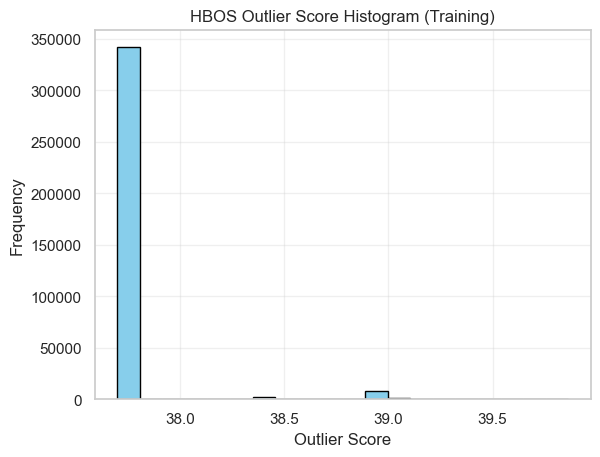

In [138]:
# Scores for training data
y_train_scores = hbos.decision_function(X_train)

plt.hist(y_train_scores, bins='auto', color='skyblue', edgecolor='black')
plt.title("HBOS Outlier Score Histogram (Training)")
plt.xlabel("Outlier Score")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### Step 3: Descriptive Statistics

In [150]:
# Determine the thresold according to the histogram
threshold = 38

def summarize_groups_by_threshold(X, scores, threshold, features):
    df = pd.DataFrame(X, columns=features)
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")
    
    cnt = df.groupby("Group").size().reset_index(name="Count")
    cnt["Count %"] = cnt["Count"] / cnt["Count"].sum() * 100
    
    means = df.groupby("Group").mean().round(2).reset_index()
    result = cnt.merge(means, on="Group")
    
    return result

In [152]:
(summarize_groups_by_threshold(X_train, y_train_scores, threshold, list(X_train.columns)))

,Group,Count,Count %,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean,Anomaly_Score
0,Normal,342044,96.63188,-1.582723e+11,0.64,-1.907542e+11,0.69,0.60,0.60,0.78,-2.501904e+11,-1.907542e+11,0.70,-1.582723e+11,0.65,37.7
1,Outlier,11922,3.36812,4.540856e+12,11.26,8.460000e+00,9.74,12.25,12.25,7.68,9.827321e+12,6.730000e+00,9.61,4.540856e+12,11.00,38.9


In [153]:
(summarize_groups_by_threshold(X_test, y_test_scores, threshold, list(X_test.columns)))

,Group,Count,Count %,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean,Anomaly_Score
0,Normal,85544,96.668625,0.85,0.64,7.627225e+11,0.68,0.59,0.59,0.73,-2.990522e+10,7.627225e+11,0.69,0.85,0.65,37.70
1,Outlier,2948,3.331375,5.02,11.68,1.058000e+01,10.86,13.75,13.94,7.54,-9.846328e+12,7.870000e+00,10.46,5.00,11.13,38.89


In [167]:
def confusion_matrix(actual,score, threshold):
    Actual_pred = pd.DataFrame({'Actual': actual, 'Pred': score})
    Actual_pred['Pred'] = np.where(Actual_pred['Pred']<=threshold,0,1)
    cm = pd.crosstab(Actual_pred['Actual'],Actual_pred['Pred'])
    return (cm)

In [169]:
y_train = np.zeros_like(y_train_scores)

confusion_matrix(y_train,y_train_scores,threshold)

Pred,0,1
Actual,,
0.0,342044,11922


In [170]:
y_test = np.zeros_like(y_test_scores)

confusion_matrix(y_test,y_test_scores,threshold)

Pred,0,1
Actual,,
0.0,85544,2948


### Step 4: Achieve Model Stability by Aggregating Multiple Models

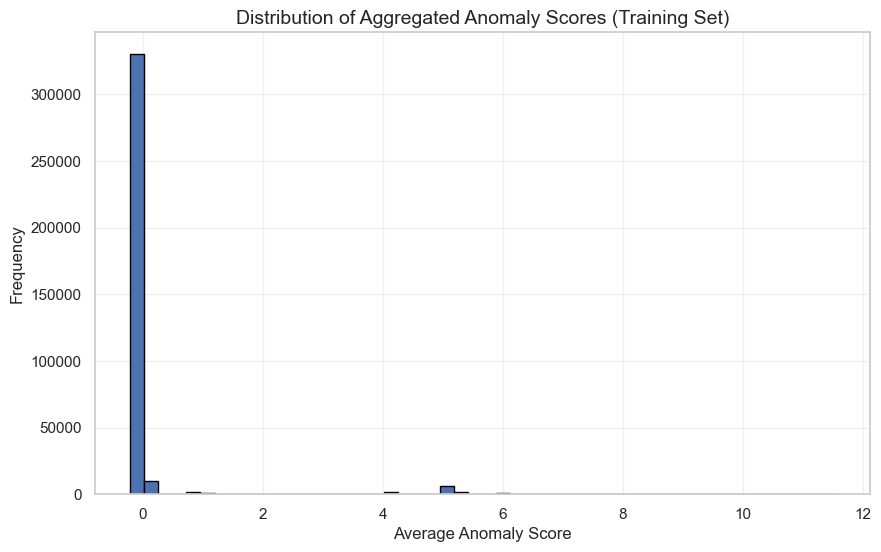

In [171]:
# Define range of bin numbers for HBOS
k_list = [5, 10, 15, 20, 25, 30, 50, 60, 75, 100]
n_clf = len(k_list)

# Prepare arrays to hold decision scores
train_scores = np.zeros((X_train.shape[0], n_clf))
test_scores = np.zeros((X_test.shape[0], n_clf))

# Fit HBOS with different bin sizes
for i, k in enumerate(k_list):
    hbos = HBOS(n_bins=k)
    hbos.fit(X_train)
    
    # Store decision scores for train and test
    train_scores[:, i] = hbos.decision_function(X_train)
    test_scores[:, i] = hbos.decision_function(X_test)

# Normalize decision scores before aggregation
train_scores_norm, test_scores_norm = standardizer(train_scores, test_scores)

# Aggregate scores by averaging across models
y_train_by_average = average(train_scores_norm)
y_test_by_average = average(test_scores_norm)

# Plot histogram of averaged anomaly scores
plt.figure(figsize=(10, 6))
plt.hist(y_train_by_average, bins=50, edgecolor='black')
plt.title("Distribution of Aggregated Anomaly Scores (Training Set)", fontsize=14)
plt.xlabel("Average Anomaly Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [214]:
# Summarize statistics based on a threshold
threshold_avg = 3.8

summary_avg_train = summarize_groups_by_threshold(
    X_train, y_train_by_average, threshold_avg, feature_list
)

summary_avg_test = summarize_groups_by_threshold(
    X_test, y_test_by_average, threshold_avg, feature_list
)

summary_avg_train

,Group,Count,Count %,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean,Anomaly_Score
0,Normal,342548,96.774266,-1.580394e+11,0.65,-1.904735e+11,0.70,0.61,0.60,0.78,-2.498223e+11,-1.904735e+11,0.70,-1.580394e+11,0.65,-0.17
1,Outlier,11418,3.225734,4.741293e+12,11.59,8.660000e+00,9.97,12.57,12.58,7.93,1.026111e+13,6.880000e+00,9.83,4.741293e+12,11.42,5.23


In [215]:
summary_avg_test

,Group,Count,Count %,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean,Anomaly_Score
0,Normal,85672,96.813271,0.85,0.64,7.615829e+11,0.69,0.60,0.60,0.73,-3.686757e+11,7.615829e+11,0.70,0.85,0.65,-0.17
1,Outlier,2820,3.186729,5.19,12.04,1.085000e+01,11.12,14.13,14.33,7.75,3.900000e+00,8.040000e+00,10.71,5.16,11.55,5.23


### Summary of HBOS Model

The Histogram-based Outlier Score (HBOS) model was applied to the combined feature dataset using a contamination rate of 5%. HBOS detects anomalies by modeling the distribution of each feature independently with histograms and combining these scores to identify rare observations.

Threshold Selection:
The learned threshold from HBOS was approximately 37.70, identified from the training anomaly score histogram. The histogram showed a sharp peak for normal scores and a tail extending toward higher values, suggesting potential anomalies. Combined with this histogram insight, a threshold of 38 was ultimately chosen to separate normal from outlier transactions more effectively.

Outlier Detection (Training Data):
- Normal transactions: 342,548 (≈ 96.77%)
- Outliers detected: 11,418 (≈ 3.23%)
- Outliers in the training data showed substantially higher average values across key ratio features compared to normal observations. For example, while the normal group’s ratio_category_avg_amount hovered around ~0.65, outliers showed extreme averages exceeding 4.74e+12 in some features.

Outlier Detection (Test Data):
- Normal transactions: 85,672 (≈ 96.81%)
- Outliers detected: 2,820 (≈ 3.19%)
- Similar trends appeared in the test set, where outlier transactions had notably higher mean ratios across several features (e.g., ratio_category_avg_amount increased from ~0.85 in normal data to over 5.19 among outliers).

Interpretation:

The HBOS model effectively separated normal and abnormal transaction patterns. Although some ratio features exhibited extreme values due to potential data issues (e.g., negative or extremely large averages), the overall approach successfully flagged about 3% of transactions as potential anomalies. The ensemble averaging further stabilized predictions across different binning configurations.

### 6. Empirical Cumulative Outlier Detection (ECOD)

In [178]:
#!pip install statsmodels

### Step 1: Build the ECOD Model

In [179]:
from pyod.models.ecod import ECOD

# Initialize ECOD with 5% contamination
ecod = ECOD(contamination=0.05)

# Fit on your training data
ecod.fit(X_train)

# Get the learned threshold
threshold_ecod = ecod.threshold_

print(f"Threshold for ECOD (contamination 0.05): {threshold_ecod}")

Threshold for ECOD (contamination 0.05): 42.27658165233126


In [180]:
# Training predictions
y_train_scores_ecod = ecod.decision_function(X_train)
y_train_pred_ecod = ecod.predict(X_train)

# Test predictions
y_test_scores_ecod = ecod.decision_function(X_test)
y_test_pred_ecod = ecod.predict(X_test)

# Print prediction counts
def count_stat(vector):
    unique, counts = np.unique(vector, return_counts=True)
    return dict(zip(unique, counts))

print("Train prediction counts:", count_stat(y_train_pred_ecod))
print("Test prediction counts:", count_stat(y_test_pred_ecod))

Train prediction counts: {np.int64(0): np.int64(336267), np.int64(1): np.int64(17699)}
Test prediction counts: {np.int64(0): np.int64(84043), np.int64(1): np.int64(4449)}


In [203]:
pick_outliers = np.where(y_train_scores>39.8)
pick_outliers[0]

array([  4218,  10484,  15683,  20762,  34583,  37364,  46501,  56957,
        62120,  62828,  65040,  75452,  75712,  76936,  87366,  87534,
        88737,  91443,  92913, 119524, 123284, 126211, 128636, 130420,
       140505, 140506, 157292, 166212, 170772, 177338, 182708, 189137,
       190256, 194153, 207786, 210904, 214416, 222014, 232933, 246192,
       259836, 265221, 267718, 269972, 277001, 281562, 286704, 290582,
       295213, 298597, 303948, 309000, 310348, 314205, 315498, 328746,
       346084])

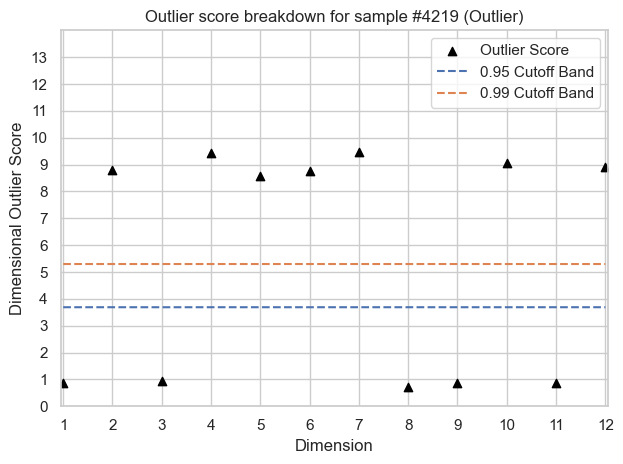

In [199]:
# Variable explainability
ecod.explain_outlier(pick_outliers[0][0])

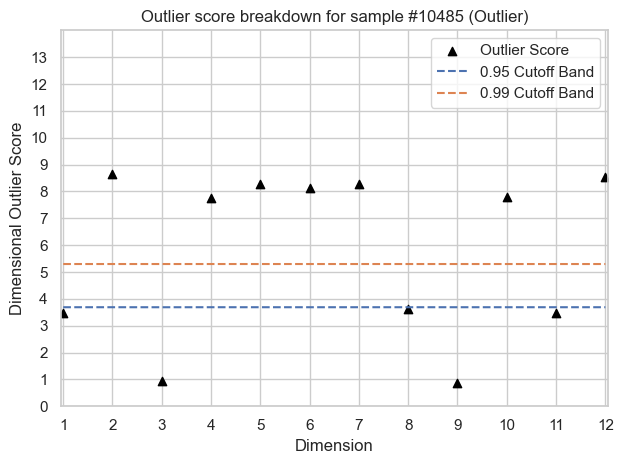

In [200]:
ecod.explain_outlier(pick_outliers[0][1])

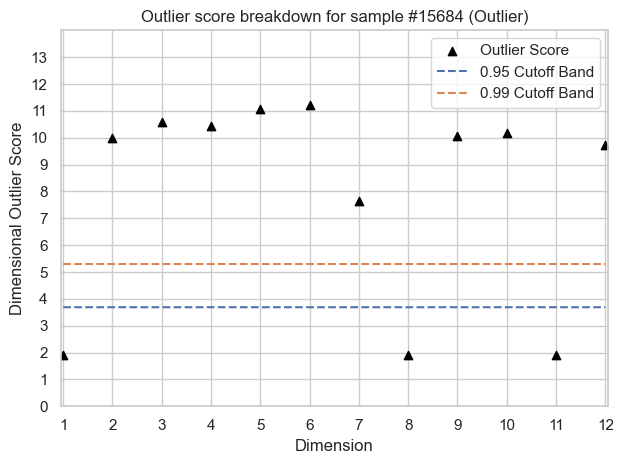

In [202]:
ecod.explain_outlier(pick_outliers[0][2])

### Step 2: Determine Threshold

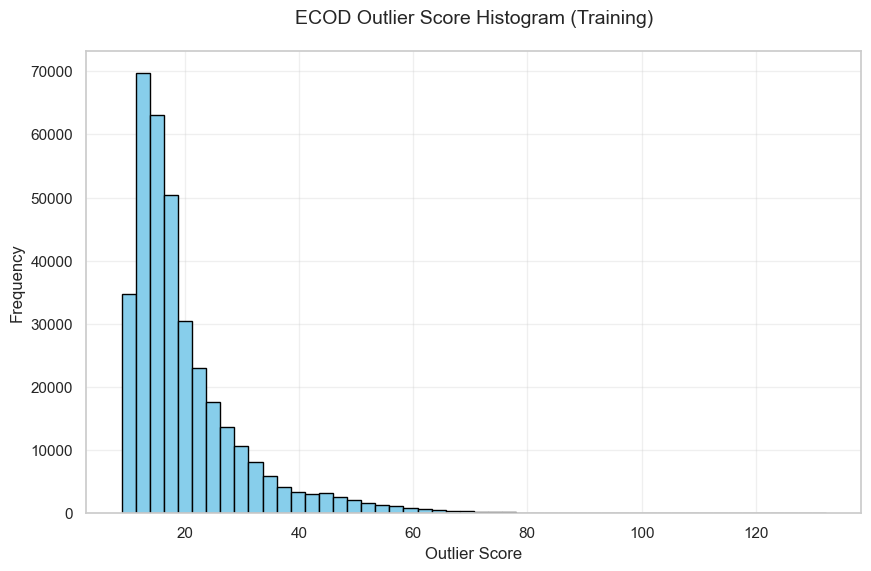

In [205]:
plt.figure(figsize=(10,6))
plt.hist(y_train_scores_ecod, bins=50, color='skyblue', edgecolor='black')
plt.title("ECOD Outlier Score Histogram (Training)", fontsize=14, pad=20)
plt.xlabel("Outlier Score", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### Step 3: Descriptive Statistics

In [207]:
# Define a function for summary stats
def summarize_groups_by_threshold(X, scores, threshold, features):
    df = pd.DataFrame(X, columns=features)
    df["Anomaly_Score"] = scores
    df["Group"] = np.where(df["Anomaly_Score"] < threshold, "Normal", "Outlier")

    cnt = df.groupby("Group").size().reset_index(name="Count")
    cnt["Count %"] = cnt["Count"] / cnt["Count"].sum() * 100

    means = df.groupby("Group").mean().round(2).reset_index()
    result = cnt.merge(means, on="Group")

    return result

In [208]:
# Run summary for training data
summary_ecod_train = summarize_groups_by_threshold(
    X_train,
    y_train_scores_ecod,
    threshold_ecod,
    list(X_train.columns)
)

print("Training Summary (ECOD):")
summary_ecod_train

Training Summary (ECOD):


,Group,Count,Count %,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean,Anomaly_Score
0,Normal,336267,94.999802,0.92,0.77,-3.688850e+10,0.76,0.68,0.68,0.89,1.659242e+11,-3.688850e+10,0.77,0.92,0.79,18.35
1,Outlier,17699,5.000198,2.47,5.27,-2.985589e+12,5.45,6.95,6.97,3.38,-1.367855e+12,-2.985589e+12,5.34,2.45,4.99,52.68


In [209]:
# Run summary for test data
summary_ecod_test = summarize_groups_by_threshold(
    X_test,
    y_test_scores_ecod,
    threshold_ecod,
    list(X_test.columns)
)

print("Testing Summary (ECOD):")
summary_ecod_test

Testing Summary (ECOD):


,Group,Count,Count %,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean,Anomaly_Score
0,Normal,84043,94.972427,0.91,0.77,7.466658e+11,0.76,0.67,0.67,0.87,9.600000e-01,7.466658e+11,0.76,0.92,0.78,18.33
1,Outlier,4449,5.027573,2.46,5.50,5.606431e+11,6.06,7.81,7.95,2.65,-7.099390e+12,5.606431e+11,5.76,2.44,5.03,52.73


In [210]:
# Confusion matrix

# For demonstration, suppose all observations are normal in absence of labels
y_train_actual = np.zeros_like(y_train_scores_ecod)
y_test_actual = np.zeros_like(y_test_scores_ecod)

def confusion_matrix_threshold(actual, score, threshold):
    preds = np.where(score <= threshold, 0, 1)
    df = pd.DataFrame({'Actual': actual, 'Pred': preds})
    cm = pd.crosstab(df['Actual'], df['Pred'])
    return cm

print("Confusion Matrix (Training):")
print(confusion_matrix_threshold(y_train_actual, y_train_scores_ecod, threshold_ecod))

print("Confusion Matrix (Testing):")
print(confusion_matrix_threshold(y_test_actual, y_test_scores_ecod, threshold_ecod))

Confusion Matrix (Training):
Pred         0      1
Actual               
0.0     336267  17699
Confusion Matrix (Testing):
Pred        0     1
Actual             
0.0     84043  4449


### Summary of ECOD Model

The Empirical Cumulative Distribution-based Outlier Detection (ECOD) model was applied to the combined feature dataset with a contamination rate of 5%. ECOD learns how extreme each feature value is relative to the empirical data distribution without assuming any parametric model.

Threshold Selection:

The learned threshold for ECOD was around 42.28, determined from the distribution of anomaly scores in the training data. Visualization of the histogram showed a heavy skew with a long tail, guiding threshold choice for defining anomalies.

Results:
- On the training data, ECOD identified approximately 5% of transactions as outliers.
- On the test data, it similarly flagged about 5% of records as anomalous, maintaining consistency between datasets.
- Summary statistics revealed that outlier groups had significantly higher averages across several ratio-based features, suggesting meaningful deviations in transaction patterns.

Explainability:

ECOD’s explain_outlier plots provided valuable insights by highlighting which specific features (dimensions) contributed most to each flagged anomaly. Many outliers exceeded the 0.95 and 0.99 cutoff bands in multiple feature dimensions, confirming substantial deviation from normal transactional behavior.

Overall, ECOD provided a transparent, non-parametric way to detect unusual patterns, helping isolate transactions with suspicious spending behaviors across various benchmarks.

### 7. Triangulating the predictions of Two Models (HBOS and ECOD)

### Step 1: Fit HBOS and ECOD Models

In [225]:
# HBOS Model
hbos = HBOS(n_bins=50, contamination=0.05)
hbos.fit(X_train)

y_train_hbos_pred = hbos.predict(X_train)
y_test_hbos_pred = hbos.predict(X_test)
y_train_hbos_scores = hbos.decision_function(X_train)
y_test_hbos_scores = hbos.decision_function(X_test)

# ECOD Model
ecod = ECOD(contamination=0.05)
ecod.fit(X_train)

y_train_ecod_pred = ecod.predict(X_train)
y_test_ecod_pred = ecod.predict(X_test)
y_train_ecod_scores = ecod.decision_function(X_train)
y_test_ecod_scores = ecod.decision_function(X_test)

# Thresholds
[ecod.threshold_, hbos.threshold_]

[np.float64(42.27658165233126), np.float64(37.70015510813827)]

### Step 2: Triangulation

In [220]:
# Create DataFrame with both predictions
compare_df = pd.DataFrame({
    'HBOS_pred': y_test_hbos_pred,
    'ECOD_pred': y_test_ecod_pred
})

# Cross-tabulation
cross_tab = pd.crosstab(compare_df['HBOS_pred'], compare_df['ECOD_pred'])
print("Cross-tabulation of HBOS and ECOD Predictions:\n")
print(cross_tab)

Cross-tabulation of HBOS and ECOD Predictions:

ECOD_pred      0     1
HBOS_pred             
0          82672  2840
1           1371  1609


### Step 3: Find indices where both models predict outlier

In [228]:
# Find indices where both models predict outlier (i.e. value 1)
indices_both_outliers = np.where(
    (y_test_hbos_pred == 1) & (y_test_ecod_pred == 1)
)[0]

print(f"Number of records flagged as outliers by both models: {len(indices_both_outliers)}")
print("Indices of overlapping outliers:", indices_both_outliers)

Number of records flagged as outliers by both models: 1609
Indices of overlapping outliers: [   64    70   101 ... 88366 88446 88488]


In [229]:
# Get the outlier records from X_test
outliers_df = X_test.iloc[indices_both_outliers]

# Print shape
print("Shape of outliers_df:", outliers_df.shape)

# Show top rows
outliers_df.head()

Shape of outliers_df: (1609, 12)


,ratio_vendor_avg_amount,ratio_category_avg_amount,ratio_description_avg_amount,ratio_agency_avg_amount,ratio_dow_avg_amount,ratio_ym_avg_amount,ratio_agency_cat_mean,ratio_agency_vendor_mean,ratio_agency_description_mean,ratio_agency_weekday_mean,ratio_category_vendor_mean,ratio_category_dow_mean
350506,7.290163,10.786746,9.335704,10.686510,10.726941,9.764464,12.285748,7.016867,8.382103,12.515183,7.290163,9.219525
79545,28.364100,23.880664,1.000000,19.074993,27.477438,28.517600,19.404819,18.710215,1.000000,18.624159,28.364100,21.327790
172720,20.223491,17.514541,1.006435,6.559775,4.928140,4.711615,20.160844,22.077592,0.955875,6.380261,20.223491,18.037513
294762,5.505843,12.274383,13.493039,10.378285,13.937394,15.295131,5.586601,2.544966,8.993846,10.337632,5.505843,11.991666
181775,1.591289,17.310919,24.992333,26.435160,19.859852,19.826444,2.342434,1.470115,3.321342,25.711741,1.591289,14.054669


### Comparison of ECOD and HBOS Models

- **Approach**
  - **ECOD**
    - Uses the Empirical Cumulative Distribution Function (ECDF) to determine how extreme each value is in the tails of the data distribution.
    - In our dataset, ECOD flagged around 5% of observations as outliers based on the cumulative tail probabilities across features.
  - **HBOS**
    - Constructs histograms for each feature to estimate the frequency of values.
    - Calculates outlier scores inversely proportional to bin frequency, flagging rare or extreme values.
    - For our data, HBOS also flagged roughly 5% of transactions as anomalies.

- **Outlier Score Calculation**
  - **ECOD**
    - Computes left- and right-tail probabilities for each feature.
    - Aggregates these tail probabilities across all features to generate a composite anomaly score.
    - ECOD in our results produced smoother, gradually increasing anomaly scores with a clear long right tail in the histogram.
  - **HBOS**
    - Calculates outlier scores from how infrequently values fall into histogram bins.
    - Higher scores indicate lower frequency and potential anomaly.
    - In our analysis, HBOS scores clustered near a threshold with a sharp drop-off, reflecting its histogram binning nature.

- **Assumptions**
  - Both methods assume **independence among features**.
  - ECOD’s tail-probability calculations are distribution-free and can handle a wide variety of distributions.
  - HBOS is sensitive to histogram binning; inappropriate bin choices can cause instability in outlier scoring for highly skewed data.

- **Scalability**
  - **ECOD**
    - Computationally efficient and well-suited to large datasets like ours.
  - **HBOS**
    - Also fast and efficient but can be sensitive to binning choices, especially when dealing with high-cardinality categorical variables converted into numeric features.

- **Handling of Multivariate Data**
  - **ECOD**
    - Evaluates each feature independently, then combines the tail probabilities across dimensions.
    - Our ECOD dimensional plots highlighted which specific features contributed most to outlier scores for individual observations.
  - **HBOS**
    - Also evaluates features independently.
    - Aggregates bin-based scores, but requires careful histogram parameter tuning for accurate multivariate interpretation.

- **Explainability**
  - **ECOD**
    - Provides detailed plots that break down dimensional contributions to each observation’s outlier score.
    - In our dataset, ECOD plots helped pinpoint specific ratio features driving anomalies (e.g., extreme values in ratios like `ratio_agency_vendor_mean`).
  - **HBOS**
    - Does not inherently provide dimensional breakdowns but histogram distributions offer some manual insights into unusual bins.

- **Robustness via Triangulation**
  - Triangulating ECOD and HBOS improves confidence in true anomalies.
  - In our testing dataset:
    - **1,609 observations were flagged as outliers by both models simultaneously.**
    - These overlapping anomalies are the strongest candidates for further investigation because they combine two independent statistical perspectives.

- **Overall Observations**
  - Both models performed consistently on our data, each identifying a similar percentage of anomalies.
  - However, they sometimes flagged different observations, highlighting the value of combining methods.
  - The intersection of ECOD and HBOS predictions provides a robust shortlist of high-confidence outliers for further business or investigative review.